In [1]:
# ── LIBRERÍAS ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

# ── CHECKPOINT ─────────────────────────────────────────────
df         = pd.read_parquet(Path('../data/sp500_clean.parquet'))
last_price = pd.read_parquet(Path('../data/last_price_by_symbol.parquet'))

print(f"✅ Checkpoint cargado")
print(f"   Filas     : {len(df):,}")
print(f"   Símbolos  : {df['symbol'].nunique()}")
print(f"   Rango     : {df['date'].min().date()} → {df['date'].max().date()}")

✅ Checkpoint cargado
   Filas     : 7,237,112
   Símbolos  : 1284
   Rango     : 1990-01-02 → 2026-01-30


In [4]:
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════
# PARÁMETROS
# ══════════════════════════════════════════════════════════
LOOKBACK     = 60
N_ASSETS     = 20
INITIAL_CASH = 100_000
COMMISSION   = 0.001
RF_ANNUAL    = 0.03  # tasa libre de riesgo anual para Sharpe/Sortino

# ══════════════════════════════════════════════════════════
# PIVOTS
# ══════════════════════════════════════════════════════════
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

close_pivot = df.pivot_table(index='date', columns='symbol', values='close').sort_index()
sp500_pivot = df.pivot_table(index='date', columns='symbol', values='in_sp500').fillna(0).sort_index()

# ══════════════════════════════════════════════════════════
# SEÑAL DE MOMENTUM
# ══════════════════════════════════════════════════════════
momentum = close_pivot / close_pivot.shift(LOOKBACK) - 1
first_signal_date = momentum.dropna(how='all').index[0]

print(f"✅ Primera señal disponible: {pd.Timestamp(first_signal_date).date()}")

# ══════════════════════════════════════════════════════════
# FECHAS DE REBALANCEO
# ══════════════════════════════════════════════════════════
all_dates   = close_pivot.index
valid_dates = all_dates[all_dates >= first_signal_date]

signal_dates = (
    pd.Series(valid_dates)
    .groupby([pd.Series(valid_dates).dt.year,
              pd.Series(valid_dates).dt.month])
    .last()
    .values
)

rebal_pairs = []
for sd in signal_dates:
    sd     = pd.Timestamp(sd)
    future = all_dates[all_dates > sd]
    if len(future) > 0:
        rebal_pairs.append((sd, pd.Timestamp(future[0])))

print(f"✅ Total rebalanceos : {len(rebal_pairs)}")

# ══════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════
def get_close(symbol, date):
    if symbol in close_pivot.columns and date in close_pivot.index:
        p = close_pivot.at[date, symbol]
        if pd.notna(p) and p > 0:
            return float(p)
    return None

def get_last_known_close(symbol, before_date):
    if symbol in close_pivot.columns:
        past = close_pivot[symbol].loc[:before_date].dropna()
        if not past.empty:
            return float(past.iloc[-1])
    return 0.0

# ══════════════════════════════════════════════════════════
# ENGINE
# ══════════════════════════════════════════════════════════
portfolio        = {}
last_rebal_price = {}
cash             = INITIAL_CASH
nav_history      = []
trade_log        = []
composition_log  = []   # ← NUEVO: composición y pesos por rebalanceo

for signal_date, exec_date in rebal_pairs:

    if signal_date not in momentum.index:
        continue

    # ── 0. MARK-TO-MARKET ─────────────────────────────────
    for symbol in list(portfolio.keys()):
        old_price = last_rebal_price[symbol]
        new_price = get_close(symbol, exec_date)
        if new_price is None:
            new_price = get_last_known_close(symbol, exec_date)
        ret = (new_price / old_price) if old_price > 0 else 0.0
        portfolio[symbol]        *= ret
        last_rebal_price[symbol]  = new_price

    # ── 1. UNIVERSO VÁLIDO EN T ────────────────────────────
    scores = momentum.loc[signal_date].dropna()

    if signal_date in sp500_pivot.index:
        sp500_today   = sp500_pivot.loc[signal_date]
        valid_symbols = sp500_today[sp500_today == 1].index
    else:
        valid_symbols = pd.Index([])

    valid_scores = scores[
        scores.index.isin(valid_symbols) &
        scores.index.map(lambda s: get_close(s, exec_date) is not None)
    ]

    top20         = set(valid_scores.nlargest(N_ASSETS).index)
    portfolio_set = set(portfolio.keys())

    group_a = portfolio_set & top20
    group_b = portfolio_set - top20
    group_c = top20 - portfolio_set

    # ── PASO 2: VENDER GRUPO B ─────────────────────────────
    for symbol in group_b:
        capital_value = portfolio[symbol]
        price         = last_rebal_price[symbol]
        commission    = capital_value * COMMISSION
        cash         += capital_value - commission

        trade_log.append({
            'date': exec_date, 'symbol': symbol, 'action': 'SELL',
            'capital': capital_value, 'price': price, 'commission': commission,
        })
        del portfolio[symbol]
        del last_rebal_price[symbol]

    # ── PASO 3: COMPRAR GRUPO C ────────────────────────────
    n_to_buy = len(group_c)

    if n_to_buy > 0 and cash > 0:
        capital_per_asset = cash / n_to_buy

        for symbol in group_c:
            price = get_close(symbol, exec_date)
            if price is None or price <= 0:
                continue

            invested_capital = capital_per_asset / (1 + COMMISSION)
            commission       = invested_capital * COMMISSION
            cash            -= capital_per_asset

            portfolio[symbol]        = invested_capital
            last_rebal_price[symbol] = price

            trade_log.append({
                'date': exec_date, 'symbol': symbol, 'action': 'BUY',
                'capital': invested_capital, 'price': price, 'commission': commission,
            })

    cash = max(cash, 0.0)

    # ── NAV Y COMPOSICIÓN ─────────────────────────────────
    nav_after = cash + sum(portfolio.values())

    nav_history.append({
        'date': exec_date, 'nav': nav_after, 'cash': cash,
        'n_positions': len(portfolio), 'n_bought': len(group_c),
        'n_sold': len(group_b), 'n_kept': len(group_a),
        'pct_invested': (nav_after - cash) / nav_after * 100 if nav_after > 0 else 0,
    })

    # ── REGISTRO DE COMPOSICIÓN ────────────────────────────
    for symbol, capital in portfolio.items():
        composition_log.append({
            'date'       : exec_date,
            'symbol'     : symbol,
            'capital'    : capital,
            'weight_pct' : capital / nav_after * 100 if nav_after > 0 else 0,
            'nav'        : nav_after,
        })
    # También registramos el cash como posición
    composition_log.append({
        'date'      : exec_date,
        'symbol'    : '_CASH',
        'capital'   : cash,
        'weight_pct': cash / nav_after * 100 if nav_after > 0 else 0,
        'nav'       : nav_after,
    })

# ── DATAFRAMES FINALES ─────────────────────────────────────
nav_df   = pd.DataFrame(nav_history)
trade_df = pd.DataFrame(trade_log)
comp_df  = pd.DataFrame(composition_log)

print("\n" + "═" * 50)
print("📊 RESUMEN DEL BACKTEST")
print("═" * 50)
print(f"  Capital inicial    : {INITIAL_CASH:>12,.2f} €")
print(f"  NAV final          : {nav_df['nav'].iloc[-1]:>12,.2f} €")
print(f"  Retorno total      : {(nav_df['nav'].iloc[-1] / INITIAL_CASH - 1) * 100:>11.2f} %")
print(f"  Total operaciones  : {len(trade_df):>12,}")
print(f"  Comisiones totales : {trade_df['commission'].sum():>11,.2f} €")
print(f"\n  Muestra comp_df:")
print(comp_df[comp_df['symbol'] != '_CASH'].head(10).to_string(index=False))

✅ Primera señal disponible: 1990-03-28
✅ Total rebalanceos : 430

══════════════════════════════════════════════════
📊 RESUMEN DEL BACKTEST
══════════════════════════════════════════════════
  Capital inicial    :   100,000.00 €
  NAV final          : 7,998,242.41 €
  Retorno total      :     7898.24 %
  Total operaciones  :       10,722
  Comisiones totales : 1,220,499.15 €

  Muestra comp_df:
      date      symbol   capital  weight_pct        nav
1990-04-02  TKA-199108 4995.0050      5.0000 99900.0999
1990-04-02 INGR-200611 4995.0050      5.0000 99900.0999
1990-04-02          DE 4995.0050      5.0000 99900.0999
1990-04-02  CYR-199606 4995.0050      5.0000 99900.0999
1990-04-02  CKL-199505 4995.0050      5.0000 99900.0999
1990-04-02         NKE 4995.0050      5.0000 99900.0999
1990-04-02  AGC-200108 4995.0050      5.0000 99900.0999
1990-04-02         FDX 4995.0050      5.0000 99900.0999
1990-04-02  CTX-200908 4995.0050      5.0000 99900.0999
1990-04-02        INTC 4995.0050      5.00

In [5]:
# ══════════════════════════════════════════════════════════
# MÉTRICAS DE PERFORMANCE
# ══════════════════════════════════════════════════════════

nav_series = nav_df.set_index('date')['nav'].sort_index()

# Retornos mensuales
monthly_returns = nav_series.pct_change().dropna()

# ── CAGR ──────────────────────────────────────────────────
n_years = (nav_series.index[-1] - nav_series.index[0]).days / 365.25
cagr    = (nav_series.iloc[-1] / nav_series.iloc[0]) ** (1 / n_years) - 1

# ── VOLATILIDAD ANUALIZADA ────────────────────────────────
vol_annual = monthly_returns.std() * np.sqrt(12)

# ── SHARPE ────────────────────────────────────────────────
rf_monthly = (1 + RF_ANNUAL) ** (1/12) - 1
excess_ret = monthly_returns - rf_monthly
sharpe     = (excess_ret.mean() / excess_ret.std()) * np.sqrt(12)

# ── SORTINO ───────────────────────────────────────────────
downside_ret  = monthly_returns[monthly_returns < rf_monthly]
downside_std  = downside_ret.std() * np.sqrt(12)
sortino       = (cagr - RF_ANNUAL) / downside_std if downside_std > 0 else np.nan

# ── MAX DRAWDOWN ──────────────────────────────────────────
rolling_max  = nav_series.cummax()
drawdown     = (nav_series - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Duración del max drawdown
dd_end   = drawdown.idxmin()
dd_start = nav_series[:dd_end].idxmax()
dd_days  = (dd_end - dd_start).days

# ── CALMAR RATIO ──────────────────────────────────────────
calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

# ── WIN RATE MENSUAL ──────────────────────────────────────
win_rate = (monthly_returns > 0).sum() / len(monthly_returns) * 100

# ── BEST / WORST MES ──────────────────────────────────────
best_month  = monthly_returns.max()
worst_month = monthly_returns.min()

# ── PROFIT FACTOR ─────────────────────────────────────────
gross_profits = monthly_returns[monthly_returns > 0].sum()
gross_losses  = monthly_returns[monthly_returns < 0].abs().sum()
profit_factor = gross_profits / gross_losses if gross_losses > 0 else np.nan

# ── PRINT ─────────────────────────────────────────────────
print("═" * 55)
print("📈 MÉTRICAS DE PERFORMANCE — MOMENTUM STRATEGY")
print("═" * 55)
print(f"  Período analizado    : {nav_series.index[0].date()} → {nav_series.index[-1].date()}")
print(f"  Años                 : {n_years:.1f}")
print(f"\n  {'RETORNO':}")
print(f"    CAGR               : {cagr * 100:>8.2f} %")
print(f"    Retorno total      : {(nav_series.iloc[-1]/nav_series.iloc[0]-1)*100:>8.2f} %")
print(f"    Mejor mes          : {best_month * 100:>8.2f} %")
print(f"    Peor mes           : {worst_month * 100:>8.2f} %")
print(f"    Win rate mensual   : {win_rate:>8.2f} %")
print(f"\n  {'RIESGO':}")
print(f"    Volatilidad anual  : {vol_annual * 100:>8.2f} %")
print(f"    Max Drawdown       : {max_drawdown * 100:>8.2f} %")
print(f"    Inicio MDD         : {dd_start.date()}")
print(f"    Fin MDD            : {dd_end.date()}")
print(f"    Duración MDD       : {dd_days} días")
print(f"\n  {'RATIOS':}")
print(f"    Sharpe (RF=3%)     : {sharpe:>8.2f}")
print(f"    Sortino (RF=3%)    : {sortino:>8.2f}")
print(f"    Calmar             : {calmar:>8.2f}")
print(f"    Profit Factor      : {profit_factor:>8.2f}")

═══════════════════════════════════════════════════════
📈 MÉTRICAS DE PERFORMANCE — MOMENTUM STRATEGY
═══════════════════════════════════════════════════════
  Período analizado    : 1990-04-02 → 2026-01-02
  Años                 : 35.8

  RETORNO
    CAGR               :    13.04 %
    Retorno total      :  7906.24 %
    Mejor mes          :    28.61 %
    Peor mes           :   -21.65 %
    Win rate mensual   :    59.67 %

  RIESGO
    Volatilidad anual  :    22.09 %
    Max Drawdown       :   -61.53 %
    Inicio MDD         : 2007-10-01
    Fin MDD            : 2009-03-02
    Duración MDD       : 518 días

  RATIOS
    Sharpe (RF=3%)     :     0.53
    Sortino (RF=3%)    :     0.70
    Calmar             :     0.21
    Profit Factor      :     1.67


In [26]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------------------- ------- 1.3/1.6 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 7.0 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15689 sha256=2ad4ca59623920c303f21ecc5c2f4c7e53276ce8021292610a9ad9e7fde63d32
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\7e\62\f9\20d7dbb144b6f563edab8e3a7fda71d976870cd41972035cdd
Successfully built multitasking

   ---------------------------------------- 0/8 [pytz]
   ----- ---------------------------------- 1/8 [peewee]
   -------------

✅ SPY descargado: 1993-01-29 → 2025-12-31 (8,288 puntos)

═══════════════════════════════════════════════════════
📊 COMPARATIVA ESTRATEGIA vs SPY
═══════════════════════════════════════════════════════
  Métrica                  Estrategia          SPY
  ----------------------------------------------
  CAGR                         13.04%       10.67%
  Volatilidad anual            22.09%       14.73%
  Sharpe (RF=3%)                 0.53         0.56
  Max Drawdown                -61.53%      -55.19%


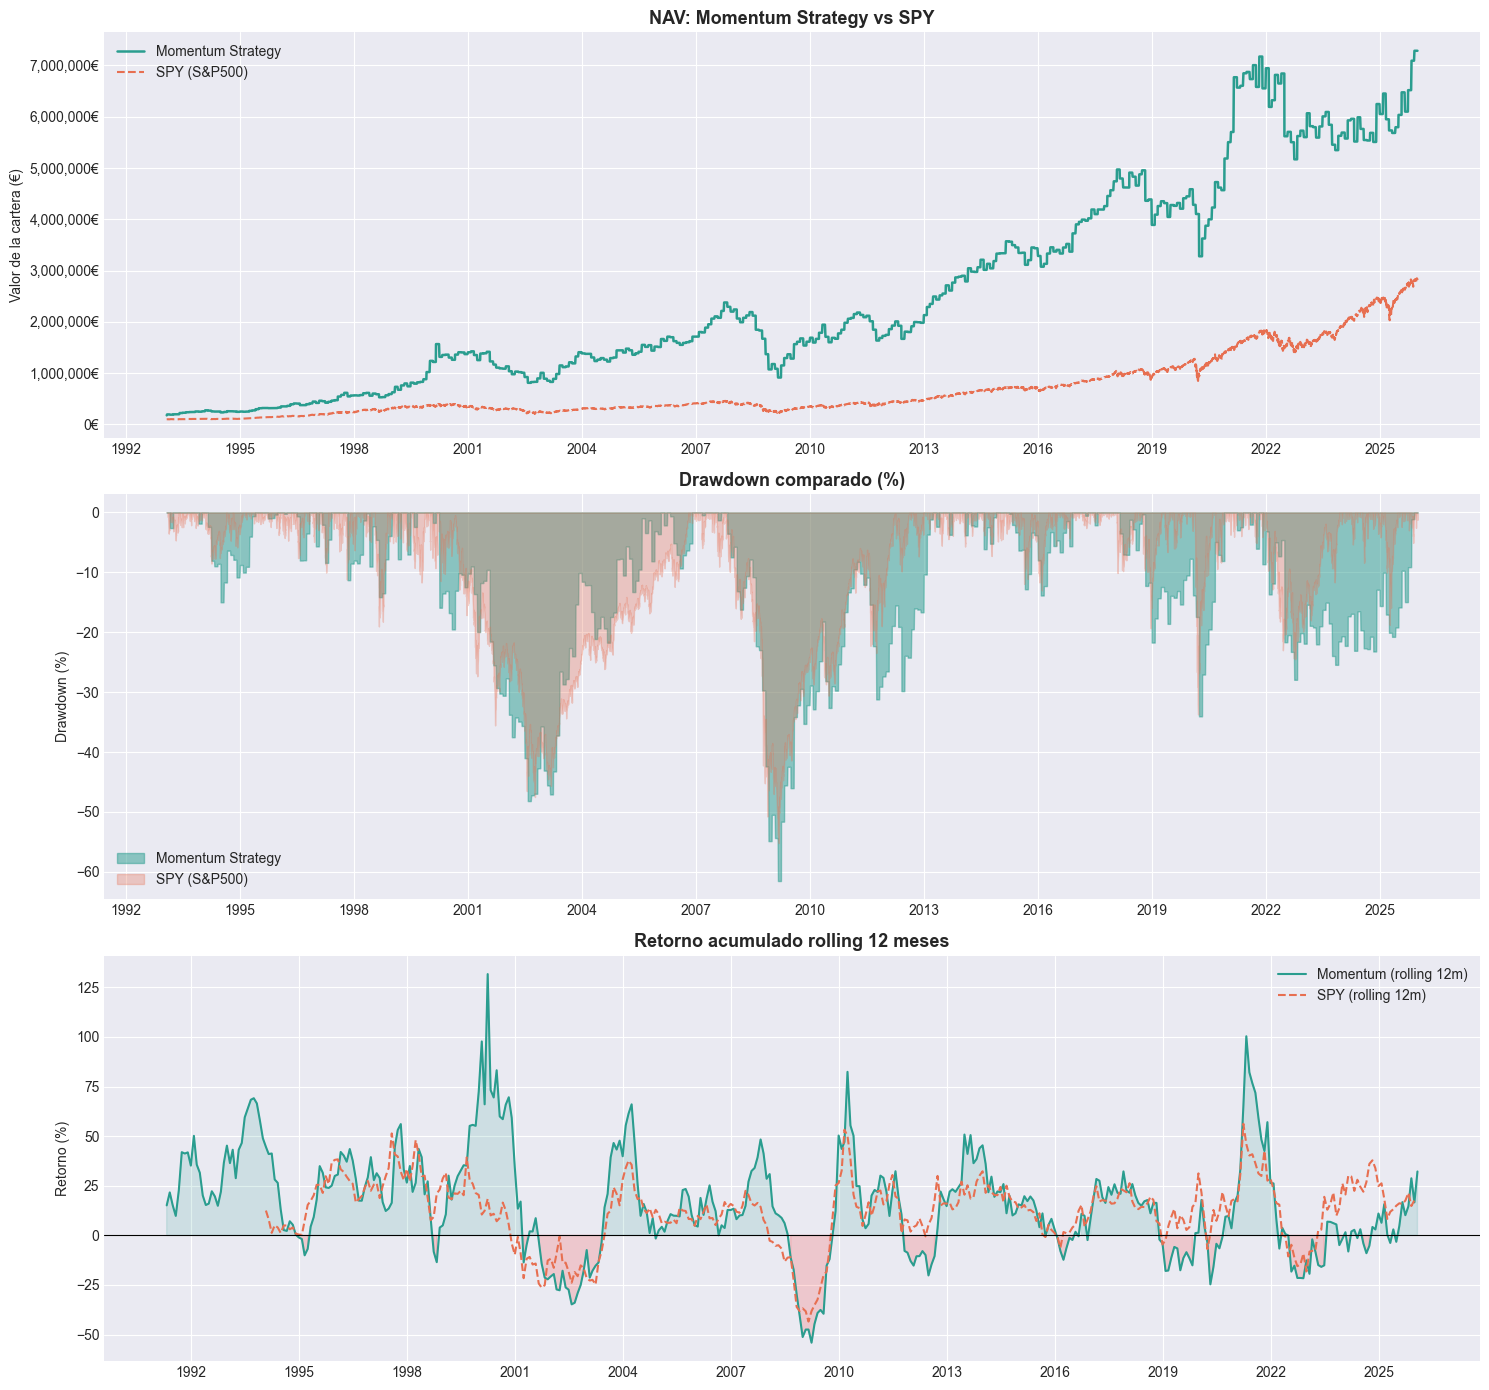

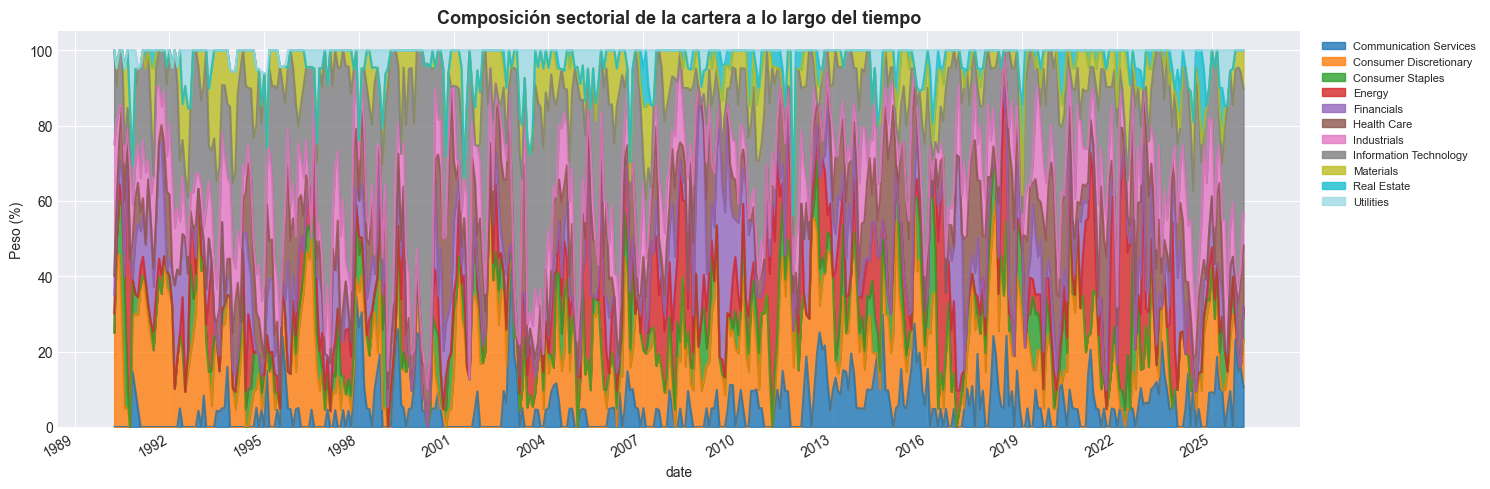

In [6]:
import yfinance as yf

# ══════════════════════════════════════════════════════════
# BENCHMARK: SPY desde Yahoo Finance
# ══════════════════════════════════════════════════════════
start_date = nav_df['date'].iloc[0]
end_date   = nav_df['date'].iloc[-1]

spy_raw   = yf.download('SPY', start=start_date, end=end_date, auto_adjust=True, progress=False)
spy_close = spy_raw['Close'].squeeze()
bm_series = spy_close / spy_close.iloc[0] * INITIAL_CASH

print(f"✅ SPY descargado: {bm_series.index[0].date()} → {bm_series.index[-1].date()} ({len(bm_series):,} puntos)")

# ══════════════════════════════════════════════════════════
# ALINEAR ESTRATEGIA CON EL ÍNDICE DIARIO DEL SPY
# ══════════════════════════════════════════════════════════
strat_series = nav_df.set_index('date')['nav'].reindex(bm_series.index, method='ffill')

# ══════════════════════════════════════════════════════════
# MÉTRICAS DEL BENCHMARK
# ══════════════════════════════════════════════════════════
rf_monthly     = (1 + RF_ANNUAL) ** (1/12) - 1
bm_monthly_ret = bm_series.resample('ME').last().pct_change().dropna()
bm_n_years     = (bm_series.index[-1] - bm_series.index[0]).days / 365.25
bm_cagr        = (bm_series.iloc[-1] / bm_series.iloc[0]) ** (1 / bm_n_years) - 1
bm_vol         = bm_monthly_ret.std() * np.sqrt(12)
bm_excess      = bm_monthly_ret - rf_monthly
bm_sharpe      = (bm_excess.mean() / bm_excess.std()) * np.sqrt(12)
bm_rolling_max = bm_series.cummax()
bm_drawdown    = (bm_series - bm_rolling_max) / bm_rolling_max
bm_max_dd      = bm_drawdown.min()

print("\n" + "═" * 55)
print("📊 COMPARATIVA ESTRATEGIA vs SPY")
print("═" * 55)
print(f"  {'Métrica':<22} {'Estrategia':>12} {'SPY':>12}")
print(f"  {'-'*46}")
print(f"  {'CAGR':<22} {cagr*100:>11.2f}% {bm_cagr*100:>11.2f}%")
print(f"  {'Volatilidad anual':<22} {vol_annual*100:>11.2f}% {bm_vol*100:>11.2f}%")
print(f"  {'Sharpe (RF=3%)':<22} {sharpe:>12.2f} {bm_sharpe:>12.2f}")
print(f"  {'Max Drawdown':<22} {max_drawdown*100:>11.2f}% {bm_max_dd*100:>11.2f}%")

# ══════════════════════════════════════════════════════════
# GRÁFICOS
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(15, 14))

# ── Gráfico 1: NAV Estrategia vs SPY ──────────────────────
axes[0].plot(strat_series.index, strat_series,
             label='Momentum Strategy', color='#2a9d8f', linewidth=1.8)
axes[0].plot(bm_series.index, bm_series,
             label='SPY (S&P500)', color='#e76f51',
             linewidth=1.5, linestyle='--')
axes[0].set_title('NAV: Momentum Strategy vs SPY', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor de la cartera (€)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator(3))

# ── Gráfico 2: Drawdown comparado ─────────────────────────
strat_dd = (strat_series - strat_series.cummax()) / strat_series.cummax() * 100
bm_dd    = bm_drawdown * 100

axes[1].fill_between(strat_dd.index, strat_dd, 0,
                     alpha=0.5, color='#2a9d8f', label='Momentum Strategy')
axes[1].fill_between(bm_dd.index, bm_dd, 0,
                     alpha=0.3, color='#e76f51', label='SPY (S&P500)')
axes[1].set_title('Drawdown comparado (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(3))

# ── Gráfico 3: Retorno rolling 12 meses ───────────────────
monthly_returns = nav_df.set_index('date')['nav'].resample('ME').last().pct_change().dropna()
strat_rolling   = (1 + monthly_returns).rolling(12).apply(np.prod) - 1
bm_rolling      = (1 + bm_monthly_ret).rolling(12).apply(np.prod) - 1

axes[2].plot(strat_rolling.index, strat_rolling * 100,
             label='Momentum (rolling 12m)', color='#2a9d8f', linewidth=1.5)
axes[2].plot(bm_rolling.index, bm_rolling * 100,
             label='SPY (rolling 12m)', color='#e76f51',
             linewidth=1.5, linestyle='--')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].fill_between(strat_rolling.index, strat_rolling * 100, 0,
                     where=(strat_rolling > 0), alpha=0.15, color='#2a9d8f')
axes[2].fill_between(strat_rolling.index, strat_rolling * 100, 0,
                     where=(strat_rolling <= 0), alpha=0.15, color='red')
axes[2].set_title('Retorno acumulado rolling 12 meses', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Retorno (%)')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator(3))

plt.tight_layout()
plt.savefig('../results/strategy_vs_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════
# GRÁFICO EXTRA: Composición sectorial de la cartera
# ══════════════════════════════════════════════════════════
sector_map = df[['symbol', 'sector']].drop_duplicates().set_index('symbol')['sector']

comp_sectors = (
    comp_df[comp_df['symbol'] != '_CASH']
    .merge(sector_map.reset_index(), on='symbol', how='left')
    .groupby(['date', 'sector'])['weight_pct']
    .sum()
    .unstack(fill_value=0)
)

fig2, ax = plt.subplots(figsize=(15, 5))
comp_sectors.plot.area(ax=ax, alpha=0.8, colormap='tab20')
ax.set_title('Composición sectorial de la cartera a lo largo del tiempo',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Peso (%)')
ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.01, 1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(3))
plt.tight_layout()
plt.savefig('../results/sector_composition.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
import pandas as pd

# 1. Convertimos el historial de pesos a DataFrame (por si no lo tenías ya)
holdings_df_full = pd.DataFrame(holdings_history).set_index('date').fillna(0)

# 2. Buscamos el peso máximo absoluto en toda la historia de la matriz
max_weight_ever = holdings_df_full.max().max()

# 3. Identificamos a qué ticker (columna) pertenece ese peso máximo
stock_max_weight = holdings_df_full.max().idxmax()

# 4. Buscamos en qué fecha exacta (índice) se dio ese pico de concentración
date_max_weight = holdings_df_full[stock_max_weight].idxmax()

print("\n" + "═" * 50)
print("🔍 ANÁLISIS DE CONCENTRACIÓN MÁXIMA")
print("═" * 50)
print(f"⚠️ El mayor peso de una sola acción fue: {max_weight_ever:.2f} %")
print(f"   Acción: {stock_max_weight}")
print(f"   Fecha : {date_max_weight.date()}")
print("═" * 50)


══════════════════════════════════════════════════
🔍 ANÁLISIS DE CONCENTRACIÓN MÁXIMA
══════════════════════════════════════════════════
⚠️ El mayor peso de una sola acción fue: 16.12 %
   Acción: DIGI-199809
   Fecha : 1993-02-01
══════════════════════════════════════════════════


In [8]:
# ══════════════════════════════════════════════════════════
# ANÁLISIS DE LAS MAYORES PONDERACIONES POR REBALANCEO
# ══════════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("🏆 TOP 1 PONDERACIÓN EN CADA REBALANCEO (Excluyendo Cash)")
print("═" * 60)

# 1. Filtramos para no tener en cuenta el dinero en efectivo
comp_no_cash = comp_df[comp_df['symbol'] != '_CASH'].copy()

# 2. Ordenamos por Fecha y luego por Peso (de mayor a menor)
comp_sorted = comp_no_cash.sort_values(['date', 'weight_pct'], ascending=[True, False])

# 3. Nos quedamos solo con la primera fila de cada fecha (la que más pesa)
top_weights_per_rebal = comp_sorted.drop_duplicates(subset=['date'], keep='first')

# 4. Mostramos el resultado de forma bonita (mostramos 1 de cada 12 meses para no saturar la pantalla, 
# pero puedes quitar el .iloc[::12] si quieres ver todos y cada uno de los 427 meses).
resumen_anual = top_weights_per_rebal.iloc[::12]

print(f"{'FECHA':<15} | {'ACCIÓN TOP 1':<15} | {'PESO MÁXIMO (%)'}")
print("-" * 60)
for index, row in resumen_anual.iterrows():
    print(f"{row['date'].date().strftime('%Y-%m-%d'):<15} | {row['symbol']:<15} | {row['weight_pct']:>8.2f} %")

print("-" * 60)

# 5. Opcional: ¿Cuáles han sido las 5 mayores concentraciones de TODO el backtest?
print("\n🔥 LAS 5 MAYORES CONCENTRACIONES HISTÓRICAS DE LA ESTRATEGIA 🔥")
top_5_historico = comp_no_cash.nlargest(5, 'weight_pct')
print(f"{'FECHA':<15} | {'ACCIÓN':<15} | {'PESO MÁXIMO (%)'}")
print("-" * 60)
for index, row in top_5_historico.iterrows():
    print(f"{row['date'].date().strftime('%Y-%m-%d'):<15} | {row['symbol']:<15} | {row['weight_pct']:>8.2f} %")
print("═" * 60)


════════════════════════════════════════════════════════════
🏆 TOP 1 PONDERACIÓN EN CADA REBALANCEO (Excluyendo Cash)
════════════════════════════════════════════════════════════
FECHA           | ACCIÓN TOP 1    | PESO MÁXIMO (%)
------------------------------------------------------------
1990-04-02      | TKA-199108      |     5.00 %
1991-04-01      | DGN-199910      |     6.24 %
1992-04-01      | WAN.B-199309    |     7.19 %
1993-04-01      | CCI-199810      |     5.48 %
1994-04-04      | CPQ-200205      |     7.77 %
1995-04-03      | MU              |     5.60 %
1996-04-01      | TJX             |     6.39 %
1997-04-01      | DELL-201310     |     8.04 %
1998-04-01      | AZA-200106      |     5.87 %
1999-04-01      | SCHW            |    10.54 %
2000-04-03      | NTAP            |    10.67 %
2001-04-02      | DDS             |     7.81 %
2002-04-01      | PVN-200509      |    10.04 %
2003-04-01      | DYN-201804      |     7.37 %
2004-04-01      | AWE-200410      |     5.92 %
20

VAMOS A HACER AHORA UN BACKTESTING MUCHO MÁS REALISTA ( DESDE EL 2005, CON CASH INICIAL DE 10000 DÓILARES, SLIPAGGE Y COISIONES DE IBKR)

In [9]:
# ── LIBRERÍAS ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

# ── CHECKPOINT Y FILTRADO ──────────────────────────────────
print("Cargando datos...")
df = pd.read_parquet(Path('../data/sp500_clean.parquet'))

# ⚡ NUEVO: Filtramos drásticamente desde 2005 para evitar el sesgo de la muestra anterior
df = df[df['date'] >= '2005-01-01'].copy()
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print(f"✅ Datos filtrados")
print(f"   Filas     : {len(df):,}")
print(f"   Símbolos  : {df['symbol'].nunique()}")
print(f"   Rango     : {df['date'].min().date()} → {df['date'].max().date()}")

# ── PARÁMETROS REALISTAS ───────────────────────────────────
LOOKBACK       = 60
N_ASSETS       = 20
INITIAL_CASH   = 10_000   # ⚡ NUEVO: Capital realista (10K)
SLIPPAGE       = 0.002    # ⚡ NUEVO: 20 bps de castigo en el precio de ejecución
MIN_COMMISSION = 1.0      # ⚡ NUEVO: Comisión mínima de 1 divisa (estilo IBKR / Trade Republic)
SHARE_COMM     = 0.005    # ⚡ NUEVO: Estilo IBKR (0.005 por acción). Si usas Trade Republic puro, esto sería 0.
RF_ANNUAL      = 0.03

Cargando datos...
✅ Datos filtrados
   Filas     : 3,981,020
   Símbolos  : 1028
   Rango     : 2005-01-03 → 2026-01-30


In [10]:
# ── PIVOTS ─────────────────────────────────────────────────
print("\nConstruyendo matrices (Pivots)...")

# Matriz para la SEÑAL y el MARK-TO-MARKET
close_pivot = df.pivot_table(index='date', columns='symbol', values='close').sort_index()

# ⚡ NUEVA Matriz para la EJECUCIÓN (Slippage, Comisiones y Acciones enteras)
unadj_pivot = df.pivot_table(index='date', columns='symbol', values='unadjusted_close').sort_index()

# Matriz del Universo
sp500_pivot = df.pivot_table(index='date', columns='symbol', values='in_sp500').fillna(0).sort_index()


Construyendo matrices (Pivots)...


In [11]:
# ── SEÑAL DE MOMENTUM (En base al cierre ajustado) ─────────
momentum = close_pivot / close_pivot.shift(LOOKBACK) - 1
first_signal_date = momentum.dropna(how='all').index[0]

print(f"✅ Primera señal disponible: {pd.Timestamp(first_signal_date).date()}")

# ── FECHAS DE REBALANCEO (T y T+1) ─────────────────────────
all_dates   = close_pivot.index
valid_dates = all_dates[all_dates >= first_signal_date]

# Obtenemos el último día de cada mes
signal_dates = (
    pd.Series(valid_dates)
    .groupby([pd.Series(valid_dates).dt.year,
              pd.Series(valid_dates).dt.month])
    .last()
    .values
)

rebal_pairs = []
for sd in signal_dates:
    sd     = pd.Timestamp(sd)
    future = all_dates[all_dates > sd]
    if len(future) > 0:
        # Tupla: (Día que miramos datos 'T', Día que compramos/vendemos 'T+1')
        rebal_pairs.append((sd, pd.Timestamp(future[0])))

print(f"✅ Total rebalanceos programados: {len(rebal_pairs)}")

✅ Primera señal disponible: 2005-03-31
✅ Total rebalanceos programados: 250


In [12]:
# ══════════════════════════════════════════════════════════
# HELPERS (Actualizados)
# ══════════════════════════════════════════════════════════
def get_close(symbol, date):
    if symbol in close_pivot.columns and date in close_pivot.index:
        p = close_pivot.at[date, symbol]
        if pd.notna(p) and p > 0:
            return float(p)
    return None

def get_unadj_close(symbol, date):
    if symbol in unadj_pivot.columns and date in unadj_pivot.index:
        p = unadj_pivot.at[date, symbol]
        if pd.notna(p) and p > 0:
            return float(p)
    return None

def get_last_known_close(symbol, before_date):
    if symbol in close_pivot.columns:
        past = close_pivot[symbol].loc[:before_date].dropna()
        if not past.empty:
            return float(past.iloc[-1])
    return 0.0

# ══════════════════════════════════════════════════════════
# ENGINE (El Motor Realista)
# ══════════════════════════════════════════════════════════
portfolio        = {}  # Guardará: symbol -> capital_actual
last_rebal_price = {}  # Guardará: symbol -> precio_ajustado_anterior
cash             = INITIAL_CASH
nav_history      = []
trade_log        = []
composition_log  = []

print("Arrancando motor de backtest realista...")

for signal_date, exec_date in rebal_pairs:

    if signal_date not in momentum.index:
        continue

    # ── 0. MARK-TO-MARKET Y DELISTINGS ────────────────────
    # Actualizamos el valor de lo que ya tenemos en cartera
    for symbol in list(portfolio.keys()):
        old_price = last_rebal_price[symbol]
        new_price = get_close(symbol, exec_date)
        
        # Si new_price es None, la acción ha desaparecido (Quiebra / Adquisición)
        if new_price is None:
            new_price = get_last_known_close(symbol, exec_date)
            print(f"⚠️ {exec_date.date()} - {symbol} desapareció. Liquidando al último precio: {new_price:.2f}")
            # Forzamos su venta en el paso 2 poniéndola en el grupo B
        
        # Calculamos la rentabilidad mensual gracias al precio ajustado
        ret = (new_price / old_price) if old_price > 0 else 0.0
        portfolio[symbol]        *= ret
        last_rebal_price[symbol]  = new_price

    # ── 1. UNIVERSO VÁLIDO EN T ────────────────────────────
    scores = momentum.loc[signal_date].dropna()

    if signal_date in sp500_pivot.index:
        sp500_today   = sp500_pivot.loc[signal_date]
        valid_symbols = sp500_today[sp500_today == 1].index
    else:
        valid_symbols = pd.Index([])

    # Solo permitimos comprar si existe precio REAL en T+1
    valid_scores = scores[
        scores.index.isin(valid_symbols) &
        scores.index.map(lambda s: get_unadj_close(s, exec_date) is not None)
    ]

    top20         = set(valid_scores.nlargest(N_ASSETS).index)
    portfolio_set = set(portfolio.keys())

    # Acciones fantasma que perdieron precio se van directas al grupo B
    for sym in list(portfolio_set):
        if get_close(sym, exec_date) is None:
            top20.discard(sym)

    group_a = portfolio_set & top20  # Mantenemos
    group_b = portfolio_set - top20  # Vendemos
    group_c = top20 - portfolio_set  # Compramos nuevos

    # ── 2. VENDER GRUPO B ──────────────────────────────────
    for symbol in group_b:
        capital_value = portfolio[symbol]
        
        # Aplicamos Slippage de venta (vendemos un poco más barato)
        capital_value_after_slip = capital_value * (1 - SLIPPAGE)
        
        # Cobramos comisión plana (ej. 1€ Trade Republic)
        commission = MIN_COMMISSION
        
        cash += (capital_value_after_slip - commission)

        trade_log.append({
            'date': exec_date, 'symbol': symbol, 'action': 'SELL',
            'capital': capital_value_after_slip, 'commission': commission,
            'slippage_impact': capital_value - capital_value_after_slip
        })
        del portfolio[symbol]
        del last_rebal_price[symbol]

    # ── 3. COMPRAR GRUPO C ─────────────────────────────────
    n_to_buy = len(group_c)

    if n_to_buy > 0 and cash > 0:
        capital_per_asset = cash / n_to_buy

        for symbol in group_c:
            unadj_price = get_unadj_close(symbol, exec_date)
            if unadj_price is None or unadj_price <= 0:
                continue

            # 1. Aplicamos Slippage de compra (pagamos más caro en la realidad)
            buy_price_real = unadj_price * (1 + SLIPPAGE)
            
            # 2. Calculamos ACCIONES ENTERAS que podemos comprar
            shares_to_buy = np.floor(capital_per_asset / buy_price_real)
            
            if shares_to_buy <= 0:
                # No tenemos dinero suficiente ni para 1 acción (muy común en cuentas pequeñas)
                continue
                
            # 3. Calculamos la inversión real y descontamos caja
            invested_capital = shares_to_buy * buy_price_real
            commission       = MIN_COMMISSION # 1€ por trade
            
            if cash < (invested_capital + commission):
                # Por si los decimales nos juegan una mala pasada
                continue

            cash -= (invested_capital + commission)

            # 4. Guardamos en cartera
            portfolio[symbol]        = invested_capital
            # ¡CRÍTICO! Guardamos el precio AJUSTADO para el Mark-to-Market del mes que viene
            last_rebal_price[symbol] = get_close(symbol, exec_date) 

            trade_log.append({
                'date': exec_date, 'symbol': symbol, 'action': 'BUY',
                'shares': shares_to_buy, 'real_price': buy_price_real,
                'capital': invested_capital, 'commission': commission
            })

    cash = max(cash, 0.0)

    # ── 4. NAV Y REGISTROS FINALES ─────────────────────────
    nav_after = cash + sum(portfolio.values())

    nav_history.append({
        'date': exec_date, 'nav': nav_after, 'cash': cash,
        'n_positions': len(portfolio)
    })

print("✅ Backtest completado con éxito")

Arrancando motor de backtest realista...
⚠️ 2006-01-03 - GP-200512 desapareció. Liquidando al último precio: 47.98
⚠️ 2006-04-03 - BR-200603 desapareció. Liquidando al último precio: 91.91
⚠️ 2006-09-01 - KMG-200608 desapareció. Liquidando al último precio: 70.47
⚠️ 2007-01-03 - FSL.B-200612 desapareció. Liquidando al último precio: 39.98
⚠️ 2007-03-01 - EOP-200702 desapareció. Liquidando al último precio: 55.47
⚠️ 2007-04-02 - CMX-200703 desapareció. Liquidando al último precio: 65.23
⚠️ 2007-07-02 - MEDI-200706 desapareció. Liquidando al último precio: 57.97
⚠️ 2008-09-02 - EDS-200808 desapareció. Liquidando al último precio: 24.96
⚠️ 2010-03-01 - BNI-201002 desapareció. Liquidando al último precio: 100.21
⚠️ 2014-01-02 - MOLX-201312 desapareció. Liquidando al último precio: 38.68
⚠️ 2014-05-01 - BEAM-201404 desapareció. Liquidando al último precio: 83.47
⚠️ 2015-09-01 - PLL-201508 desapareció. Liquidando al último precio: 127.11
⚠️ 2016-04-01 - GMCR-201603 desapareció. Liquidando al

Calculando métricas de rendimiento...

══════════════════════════════════════════════════
📊 INFORME FINAL DEL BACKTEST (2005 - Actualidad)
══════════════════════════════════════════════════
 💰 Capital Inicial   : 10,000.00 $
 💰 Capital Final     : 37,576.18 $
 📈 Retorno Total     : 275.76 %
 🚀 CAGR (Anualizado) : 6.59 %
 📉 Max Drawdown      : -61.94 %
--------------------------------------------------
 🔄 Total Operaciones : 6,218
 💸 Comisiones Pagadas: 6,218.00 $
 💧 Coste de Slippage : 10,825.58 $
 🧛 Total 'Fricción'  : 17,043.58 $
══════════════════════════════════════════════════


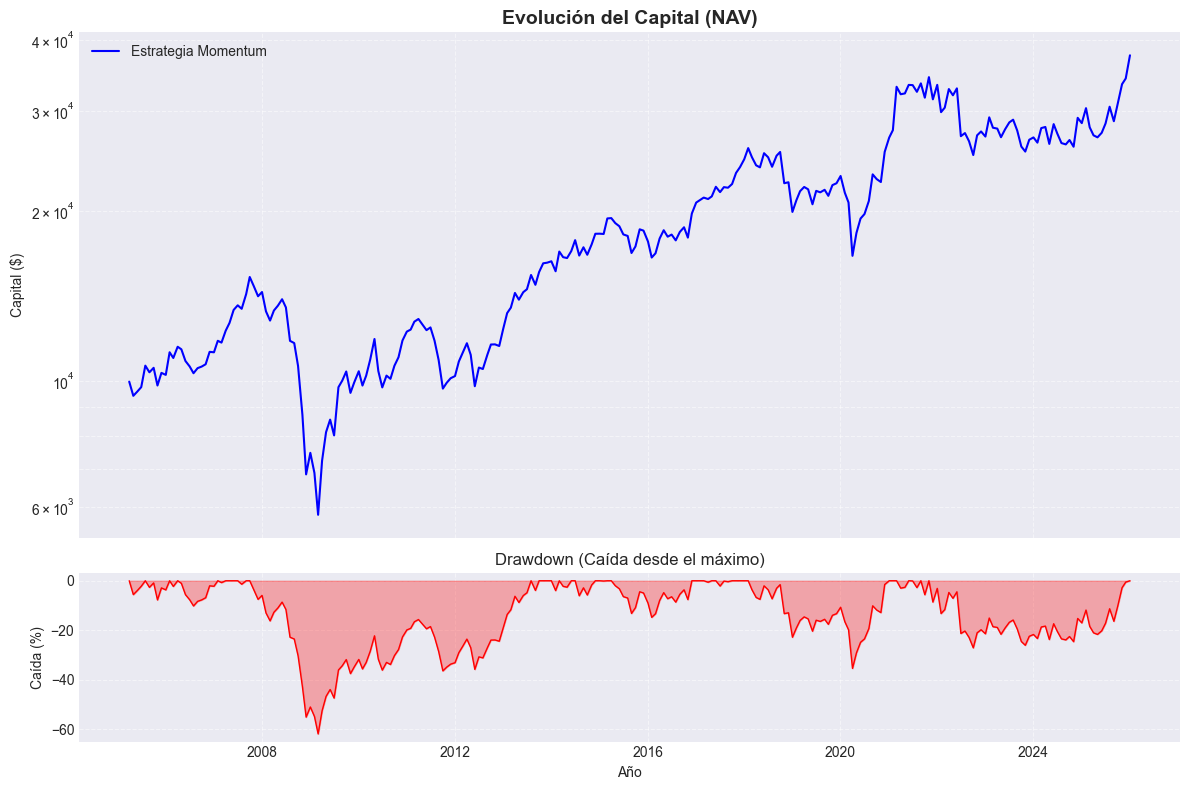

In [13]:
# ══════════════════════════════════════════════════════════
# EVALUACIÓN DE RESULTADOS (KPIs y Gráficos)
# ══════════════════════════════════════════════════════════
print("Calculando métricas de rendimiento...")

# 1. Convertimos los logs a DataFrames
nav_df   = pd.DataFrame(nav_history).set_index('date')
trade_df = pd.DataFrame(trade_log)

# 2. Métricas de Rentabilidad
initial_capital = INITIAL_CASH
final_capital   = nav_df['nav'].iloc[-1]
total_return    = (final_capital / initial_capital) - 1

# Calculamos los años que ha durado el backtest
days_passed = (nav_df.index[-1] - nav_df.index[0]).days
years       = days_passed / 365.25

# CAGR (Tasa de Crecimiento Anual Compuesta)
cagr = ((final_capital / initial_capital) ** (1 / years)) - 1

# 3. Métricas de Riesgo (Drawdown)
# Calculamos el pico máximo histórico en cada punto
nav_df['peak'] = nav_df['nav'].cummax()
# Calculamos la caída desde ese pico
nav_df['drawdown'] = (nav_df['nav'] - nav_df['peak']) / nav_df['peak']
max_drawdown = nav_df['drawdown'].min()

# 4. Costes Operativos
total_trades = len(trade_df)
total_commissions = trade_df['commission'].sum()

# Extraemos el coste del slippage de las ventas (lo guardamos en el log)
# Para las compras, podemos estimarlo (compramos al 1+SLIPPAGE, pagamos SLIPPAGE sobre el capital)
buy_trades = trade_df[trade_df['action'] == 'BUY']
sell_trades = trade_df[trade_df['action'] == 'SELL']

slippage_ventas = sell_trades['slippage_impact'].sum() if 'slippage_impact' in sell_trades.columns else 0
slippage_compras = (buy_trades['capital'] / (1 + SLIPPAGE) * SLIPPAGE).sum()
total_slippage = slippage_ventas + slippage_compras

# ── IMPRESIÓN DEL INFORME ─────────────────────────────────
print("\n" + "═" * 50)
print("📊 INFORME FINAL DEL BACKTEST (2005 - Actualidad)")
print("═" * 50)
print(f" 💰 Capital Inicial   : {initial_capital:,.2f} $")
print(f" 💰 Capital Final     : {final_capital:,.2f} $")
print(f" 📈 Retorno Total     : {total_return * 100:.2f} %")
print(f" 🚀 CAGR (Anualizado) : {cagr * 100:.2f} %")
print(f" 📉 Max Drawdown      : {max_drawdown * 100:.2f} %")
print("-" * 50)
print(f" 🔄 Total Operaciones : {total_trades:,}")
print(f" 💸 Comisiones Pagadas: {total_commissions:,.2f} $")
print(f" 💧 Coste de Slippage : {total_slippage:,.2f} $")
print(f" 🧛 Total 'Fricción'  : {(total_commissions + total_slippage):,.2f} $")
print("═" * 50)

# ── GRÁFICO DE LA CURVA DE CAPITAL Y DRAWDOWN ─────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Arriba: Curva de Capital (Escala Logarítmica suele ser mejor para plazos largos)
ax1.plot(nav_df.index, nav_df['nav'], color='blue', linewidth=1.5, label='Estrategia Momentum')
ax1.set_title('Evolución del Capital (NAV)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Capital ($)')
ax1.set_yscale('log') # Ponemos escala logarítmica para ver bien el crecimiento
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Abajo: Drawdown (Caídas)
ax2.fill_between(nav_df.index, nav_df['drawdown'] * 100, 0, color='red', alpha=0.3)
ax2.plot(nav_df.index, nav_df['drawdown'] * 100, color='red', linewidth=1)
ax2.set_title('Drawdown (Caída desde el máximo)', fontsize=12)
ax2.set_ylabel('Caída (%)')
ax2.set_xlabel('Año')
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


Descargando datos del Benchmark (SPY)...

═════════════════════════════════════════════════════════════════
          📊 COMPARATIVA: ESTRATEGIA vs BENCHMARK (SPY)           
═════════════════════════════════════════════════════════════════
Métrica              | Estrategia         | Benchmark (SPY)   
-----------------------------------------------------------------
Capital Final        |       37,576.18 $ |       85,426.15 $
CAGR (Anualizado)    |            6.60 % |           10.89 %
Max Drawdown         |          -61.94 % |          -52.90 %
Volatilidad          |           21.11 % |           16.65 %
Ratio Sharpe         |            0.27   |            0.53  
Ratio Sortino        |            0.11   |            0.19  
═════════════════════════════════════════════════════════════════


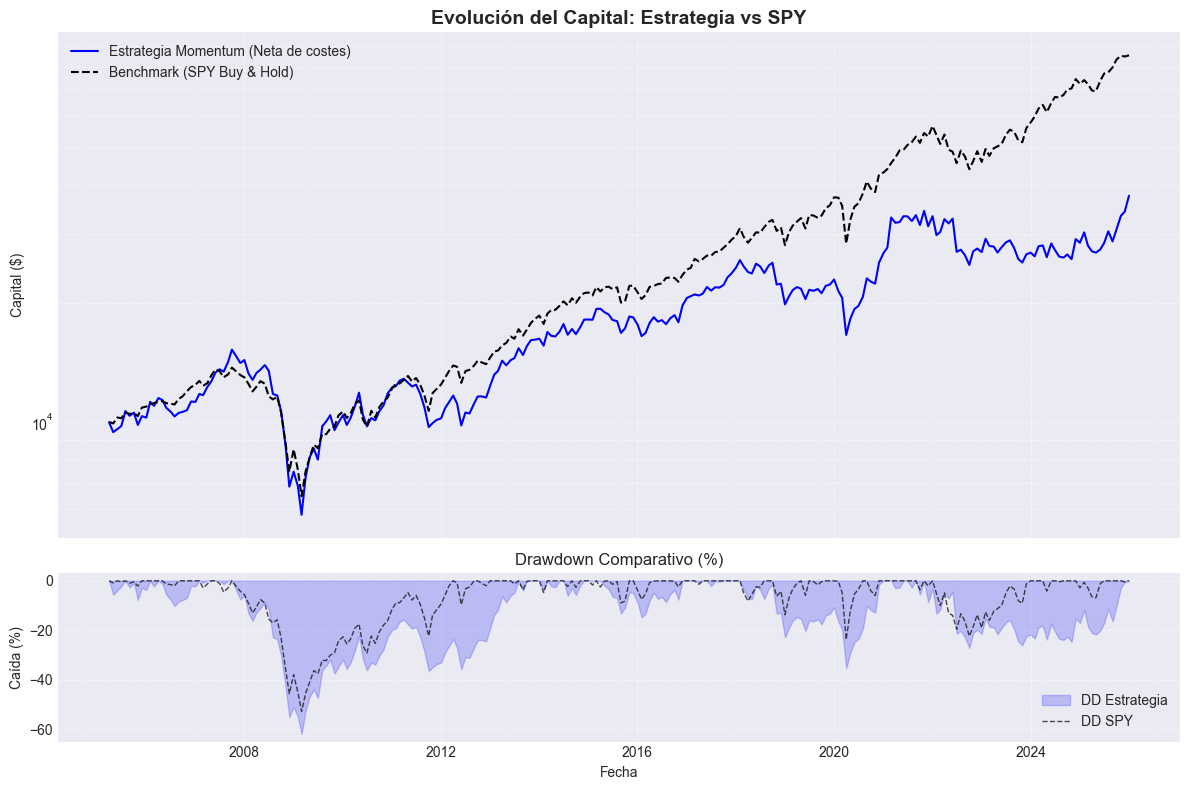

In [15]:
# ── LIBRERÍAS EXTRA NECESARIAS ─────────────────────────────
import yfinance as yf
import numpy as np

print("\nDescargando datos del Benchmark (SPY)...")

# 1. Descargamos el SPY para las fechas de nuestro backtest
start_date = nav_df.index[0]
end_date   = nav_df.index[-1] + pd.Timedelta(days=5) # Margen de seguridad

spy_data = yf.download('SPY', start=start_date, end=end_date)
# Aseguramos compatibilidad con distintas versiones de yfinance
if isinstance(spy_data.columns, pd.MultiIndex):
    spy_close = spy_data['Close']['SPY']
else:
    spy_close = spy_data['Adj Close']

# 2. Alineamos el SPY a nuestras fechas de rebalanceo (rellenando huecos)
spy_aligned = spy_close.reindex(nav_df.index, method='ffill')

# 3. Normalizamos el SPY para que empiece con nuestros mismos 10.000$
nav_df['bench_nav'] = (spy_aligned / spy_aligned.iloc[0]) * INITIAL_CASH

# 4. Calculamos los retornos periódicos (mensuales)
nav_df['strat_ret'] = nav_df['nav'].pct_change()
nav_df['bench_ret'] = nav_df['bench_nav'].pct_change()

# ── FUNCIÓN DE MÉTRICAS AVANZADAS ──────────────────────────
def calc_metrics(returns, nav_series):
    # Asumimos 12 periodos al año (rebalanceo mensual)
    PERIODS = 12
    RF_PERIODIC = (1 + RF_ANNUAL)**(1/PERIODS) - 1
    
    # CAGR
    years = (nav_series.index[-1] - nav_series.index[0]).days / 365.25
    cagr = (nav_series.iloc[-1] / nav_series.iloc[0]) ** (1 / years) - 1
    
    # Riesgo
    volatility = returns.std() * np.sqrt(PERIODS)
    
    # Max Drawdown
    peak = nav_series.cummax()
    drawdown = (nav_series - peak) / peak
    max_dd = drawdown.min()
    
    # Sharpe & Sortino
    excess_returns = returns - RF_PERIODIC
    sharpe = (excess_returns.mean() / returns.std()) * np.sqrt(PERIODS) if returns.std() > 0 else 0
    
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(PERIODS)
    sortino = (excess_returns.mean() * np.sqrt(PERIODS)) / downside_vol if downside_vol > 0 else 0
    
    return cagr, volatility, max_dd, sharpe, sortino

# Calculamos para Estrategia y Benchmark
strat_metrics = calc_metrics(nav_df['strat_ret'].dropna(), nav_df['nav'])
bench_metrics = calc_metrics(nav_df['bench_ret'].dropna(), nav_df['bench_nav'])

# ── IMPRESIÓN DEL INFORME COMPARATIVO ──────────────────────
print("\n" + "═" * 65)
print(f"{'📊 COMPARATIVA: ESTRATEGIA vs BENCHMARK (SPY)':^65}")
print("═" * 65)
print(f"{'Métrica':<20} | {'Estrategia':<18} | {'Benchmark (SPY)':<18}")
print("-" * 65)
print(f"{'Capital Final':<20} | {nav_df['nav'].iloc[-1]:>15,.2f} $ | {nav_df['bench_nav'].iloc[-1]:>15,.2f} $")
print(f"{'CAGR (Anualizado)':<20} | {strat_metrics[0]*100:>15.2f} % | {bench_metrics[0]*100:>15.2f} %")
print(f"{'Max Drawdown':<20} | {strat_metrics[2]*100:>15.2f} % | {bench_metrics[2]*100:>15.2f} %")
print(f"{'Volatilidad':<20} | {strat_metrics[1]*100:>15.2f} % | {bench_metrics[1]*100:>15.2f} %")
print(f"{'Ratio Sharpe':<20} | {strat_metrics[3]:>15.2f}   | {bench_metrics[3]:>15.2f}  ")
print(f"{'Ratio Sortino':<20} | {strat_metrics[4]:>15.2f}   | {bench_metrics[4]:>15.2f}  ")
print("═" * 65)

# ── GRÁFICO COMPARATIVO ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Curvas de Capital
ax1.plot(nav_df.index, nav_df['nav'], color='blue', linewidth=1.5, label='Estrategia Momentum (Neta de costes)')
ax1.plot(nav_df.index, nav_df['bench_nav'], color='black', linewidth=1.5, linestyle='--', label='Benchmark (SPY Buy & Hold)')
ax1.set_title('Evolución del Capital: Estrategia vs SPY', fontsize=14, fontweight='bold')
ax1.set_ylabel('Capital ($)')
ax1.set_yscale('log') 
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Drawdowns Comparativos
peak_strat = nav_df['nav'].cummax()
dd_strat = (nav_df['nav'] - peak_strat) / peak_strat

peak_bench = nav_df['bench_nav'].cummax()
dd_bench = (nav_df['bench_nav'] - peak_bench) / peak_bench

ax2.fill_between(nav_df.index, dd_strat * 100, 0, color='blue', alpha=0.2, label='DD Estrategia')
ax2.plot(nav_df.index, dd_bench * 100, color='black', linewidth=1, linestyle='--', alpha=0.7, label='DD SPY')
ax2.set_title('Drawdown Comparativo (%)', fontsize=12)
ax2.set_ylabel('Caída (%)')
ax2.set_xlabel('Fecha')
ax2.legend(loc='lower right')
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

PRUEBA CON 4 MESES DE SEÑAL DE MOMENTUM 


In [16]:
# ── LIBRERÍAS ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

# ── CHECKPOINT Y FILTRADO ──────────────────────────────────
print("Cargando datos...")
df = pd.read_parquet(Path('../data/sp500_clean.parquet'))

# ⚡ NUEVO: Filtramos drásticamente desde 2005 para evitar el sesgo de la muestra anterior
df = df[df['date'] >= '2005-01-01'].copy()
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print(f"✅ Datos filtrados")
print(f"   Filas     : {len(df):,}")
print(f"   Símbolos  : {df['symbol'].nunique()}")
print(f"   Rango     : {df['date'].min().date()} → {df['date'].max().date()}")

# ── PARÁMETROS REALISTAS ───────────────────────────────────
LOOKBACK       = 84
N_ASSETS       = 20
INITIAL_CASH   = 10_000   # ⚡ NUEVO: Capital realista (10K)
SLIPPAGE       = 0.002    # ⚡ NUEVO: 20 bps de castigo en el precio de ejecución
MIN_COMMISSION = 1.0      # ⚡ NUEVO: Comisión mínima de 1 divisa (estilo IBKR / Trade Republic)
SHARE_COMM     = 0.005    # ⚡ NUEVO: Estilo IBKR (0.005 por acción). Si usas Trade Republic puro, esto sería 0.
RF_ANNUAL      = 0.03

Cargando datos...
✅ Datos filtrados
   Filas     : 3,981,020
   Símbolos  : 1028
   Rango     : 2005-01-03 → 2026-01-30


In [17]:
# ── PIVOTS ─────────────────────────────────────────────────
print("\nConstruyendo matrices (Pivots)...")

# Matriz para la SEÑAL y el MARK-TO-MARKET
close_pivot = df.pivot_table(index='date', columns='symbol', values='close').sort_index()

# ⚡ NUEVA Matriz para la EJECUCIÓN (Slippage, Comisiones y Acciones enteras)
unadj_pivot = df.pivot_table(index='date', columns='symbol', values='unadjusted_close').sort_index()

# Matriz del Universo
sp500_pivot = df.pivot_table(index='date', columns='symbol', values='in_sp500').fillna(0).sort_index()


Construyendo matrices (Pivots)...


In [18]:
# ── SEÑAL DE MOMENTUM (En base al cierre ajustado) ─────────
momentum = close_pivot / close_pivot.shift(LOOKBACK) - 1
first_signal_date = momentum.dropna(how='all').index[0]

print(f"✅ Primera señal disponible: {pd.Timestamp(first_signal_date).date()}")

# ── FECHAS DE REBALANCEO (T y T+1) ─────────────────────────
all_dates   = close_pivot.index
valid_dates = all_dates[all_dates >= first_signal_date]

# Obtenemos el último día de cada mes
signal_dates = (
    pd.Series(valid_dates)
    .groupby([pd.Series(valid_dates).dt.year,
              pd.Series(valid_dates).dt.month])
    .last()
    .values
)

rebal_pairs = []
for sd in signal_dates:
    sd     = pd.Timestamp(sd)
    future = all_dates[all_dates > sd]
    if len(future) > 0:
        # Tupla: (Día que miramos datos 'T', Día que compramos/vendemos 'T+1')
        rebal_pairs.append((sd, pd.Timestamp(future[0])))

print(f"✅ Total rebalanceos programados: {len(rebal_pairs)}")

✅ Primera señal disponible: 2005-05-04
✅ Total rebalanceos programados: 248


In [19]:
# ══════════════════════════════════════════════════════════
# HELPERS (Actualizados)
# ══════════════════════════════════════════════════════════
def get_close(symbol, date):
    if symbol in close_pivot.columns and date in close_pivot.index:
        p = close_pivot.at[date, symbol]
        if pd.notna(p) and p > 0:
            return float(p)
    return None

def get_unadj_close(symbol, date):
    if symbol in unadj_pivot.columns and date in unadj_pivot.index:
        p = unadj_pivot.at[date, symbol]
        if pd.notna(p) and p > 0:
            return float(p)
    return None

def get_last_known_close(symbol, before_date):
    if symbol in close_pivot.columns:
        past = close_pivot[symbol].loc[:before_date].dropna()
        if not past.empty:
            return float(past.iloc[-1])
    return 0.0

# ══════════════════════════════════════════════════════════
# ENGINE (El Motor Realista)
# ══════════════════════════════════════════════════════════
portfolio        = {}  # Guardará: symbol -> capital_actual
last_rebal_price = {}  # Guardará: symbol -> precio_ajustado_anterior
cash             = INITIAL_CASH
nav_history      = []
trade_log        = []
composition_log  = []

print("Arrancando motor de backtest realista...")

for signal_date, exec_date in rebal_pairs:

    if signal_date not in momentum.index:
        continue

    # ── 0. MARK-TO-MARKET Y DELISTINGS ────────────────────
    # Actualizamos el valor de lo que ya tenemos en cartera
    for symbol in list(portfolio.keys()):
        old_price = last_rebal_price[symbol]
        new_price = get_close(symbol, exec_date)
        
        # Si new_price es None, la acción ha desaparecido (Quiebra / Adquisición)
        if new_price is None:
            new_price = get_last_known_close(symbol, exec_date)
            print(f"⚠️ {exec_date.date()} - {symbol} desapareció. Liquidando al último precio: {new_price:.2f}")
            # Forzamos su venta en el paso 2 poniéndola en el grupo B
        
        # Calculamos la rentabilidad mensual gracias al precio ajustado
        ret = (new_price / old_price) if old_price > 0 else 0.0
        portfolio[symbol]        *= ret
        last_rebal_price[symbol]  = new_price

    # ── 1. UNIVERSO VÁLIDO EN T ────────────────────────────
    scores = momentum.loc[signal_date].dropna()

    if signal_date in sp500_pivot.index:
        sp500_today   = sp500_pivot.loc[signal_date]
        valid_symbols = sp500_today[sp500_today == 1].index
    else:
        valid_symbols = pd.Index([])

    # Solo permitimos comprar si existe precio REAL en T+1
    valid_scores = scores[
        scores.index.isin(valid_symbols) &
        scores.index.map(lambda s: get_unadj_close(s, exec_date) is not None)
    ]

    top20         = set(valid_scores.nlargest(N_ASSETS).index)
    portfolio_set = set(portfolio.keys())

    # Acciones fantasma que perdieron precio se van directas al grupo B
    for sym in list(portfolio_set):
        if get_close(sym, exec_date) is None:
            top20.discard(sym)

    group_a = portfolio_set & top20  # Mantenemos
    group_b = portfolio_set - top20  # Vendemos
    group_c = top20 - portfolio_set  # Compramos nuevos

    # ── 2. VENDER GRUPO B ──────────────────────────────────
    for symbol in group_b:
        capital_value = portfolio[symbol]
        
        # Aplicamos Slippage de venta (vendemos un poco más barato)
        capital_value_after_slip = capital_value * (1 - SLIPPAGE)
        
        # Cobramos comisión plana (ej. 1€ Trade Republic)
        commission = MIN_COMMISSION
        
        cash += (capital_value_after_slip - commission)

        trade_log.append({
            'date': exec_date, 'symbol': symbol, 'action': 'SELL',
            'capital': capital_value_after_slip, 'commission': commission,
            'slippage_impact': capital_value - capital_value_after_slip
        })
        del portfolio[symbol]
        del last_rebal_price[symbol]

    # ── 3. COMPRAR GRUPO C ─────────────────────────────────
    n_to_buy = len(group_c)

    if n_to_buy > 0 and cash > 0:
        capital_per_asset = cash / n_to_buy

        for symbol in group_c:
            unadj_price = get_unadj_close(symbol, exec_date)
            if unadj_price is None or unadj_price <= 0:
                continue

            # 1. Aplicamos Slippage de compra (pagamos más caro en la realidad)
            buy_price_real = unadj_price * (1 + SLIPPAGE)
            
            # 2. Calculamos ACCIONES ENTERAS que podemos comprar
            shares_to_buy = np.floor(capital_per_asset / buy_price_real)
            
            if shares_to_buy <= 0:
                # No tenemos dinero suficiente ni para 1 acción (muy común en cuentas pequeñas)
                continue
                
            # 3. Calculamos la inversión real y descontamos caja
            invested_capital = shares_to_buy * buy_price_real
            commission       = MIN_COMMISSION # 1€ por trade
            
            if cash < (invested_capital + commission):
                # Por si los decimales nos juegan una mala pasada
                continue

            cash -= (invested_capital + commission)

            # 4. Guardamos en cartera
            portfolio[symbol]        = invested_capital
            # ¡CRÍTICO! Guardamos el precio AJUSTADO para el Mark-to-Market del mes que viene
            last_rebal_price[symbol] = get_close(symbol, exec_date) 

            trade_log.append({
                'date': exec_date, 'symbol': symbol, 'action': 'BUY',
                'shares': shares_to_buy, 'real_price': buy_price_real,
                'capital': invested_capital, 'commission': commission
            })

    cash = max(cash, 0.0)

    # ── 4. NAV Y REGISTROS FINALES ─────────────────────────
    nav_after = cash + sum(portfolio.values())

    nav_history.append({
        'date': exec_date, 'nav': nav_after, 'cash': cash,
        'n_positions': len(portfolio)
    })

print("✅ Backtest completado con éxito")

Arrancando motor de backtest realista...
⚠️ 2006-01-03 - GP-200512 desapareció. Liquidando al último precio: 47.98
⚠️ 2006-02-01 - SEBL-200601 desapareció. Liquidando al último precio: 10.61
⚠️ 2006-09-01 - KMG-200608 desapareció. Liquidando al último precio: 70.47
⚠️ 2007-03-01 - APCC-200702 desapareció. Liquidando al último precio: 30.98
⚠️ 2007-03-01 - EOP-200702 desapareció. Liquidando al último precio: 55.47
⚠️ 2007-04-02 - PD-200703 desapareció. Liquidando al último precio: 129.47
⚠️ 2007-04-02 - TSG-200703 desapareció. Liquidando al último precio: 32.75
⚠️ 2007-07-02 - MEDI-200706 desapareció. Liquidando al último precio: 57.97
⚠️ 2007-08-01 - DG-200707 desapareció. Liquidando al último precio: 21.98
⚠️ 2007-11-01 - HLT-200710 desapareció. Liquidando al último precio: 47.48
⚠️ 2008-09-02 - EDS-200808 desapareció. Liquidando al último precio: 24.96
⚠️ 2009-02-02 - UST-200901 desapareció. Liquidando al último precio: 69.46
⚠️ 2010-03-01 - RX-201002 desapareció. Liquidando al últim

Calculando métricas de rendimiento...

══════════════════════════════════════════════════
📊 INFORME FINAL DEL BACKTEST (2005 - Actualidad)
══════════════════════════════════════════════════
 💰 Capital Inicial   : 10,000.00 $
 💰 Capital Final     : 63,769.93 $
 📈 Retorno Total     : 537.70 %
 🚀 CAGR (Anualizado) : 9.42 %
 📉 Max Drawdown      : -62.21 %
--------------------------------------------------
 🔄 Total Operaciones : 5,272
 💸 Comisiones Pagadas: 5,272.00 $
 💧 Coste de Slippage : 10,943.84 $
 🧛 Total 'Fricción'  : 16,215.84 $
══════════════════════════════════════════════════


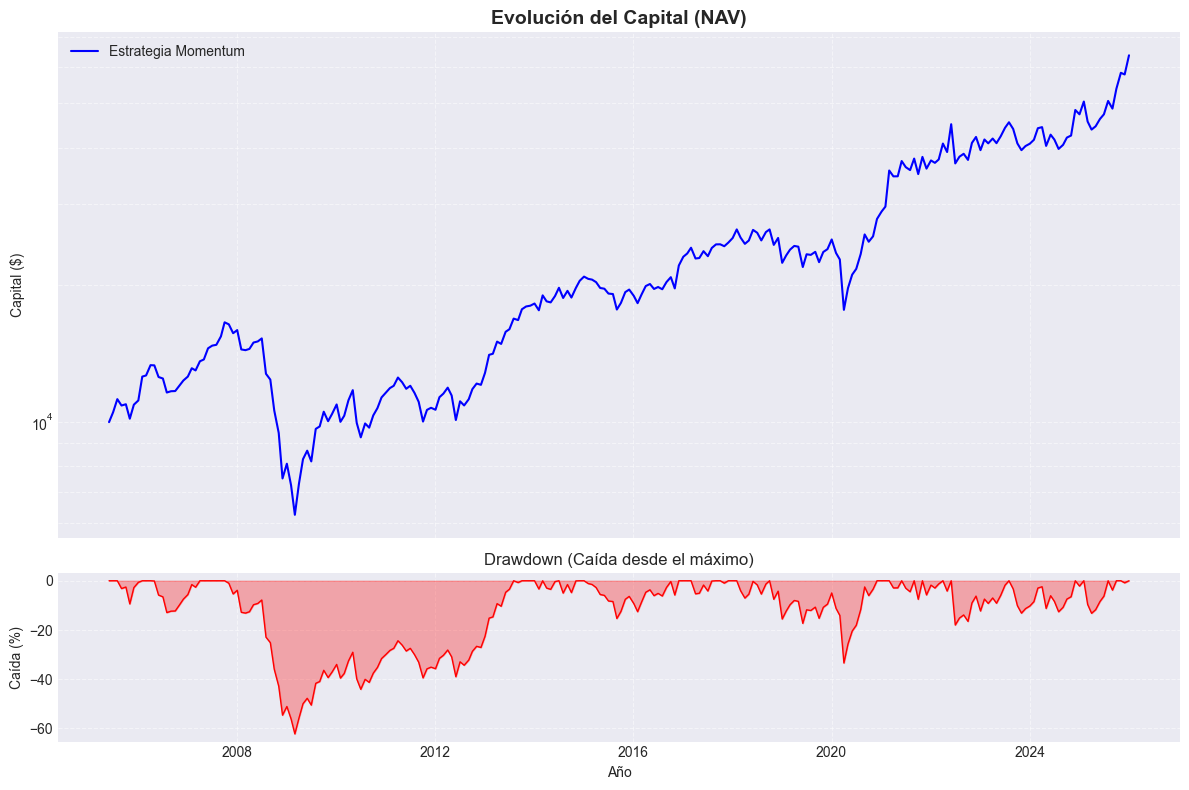

In [20]:
# ══════════════════════════════════════════════════════════
# EVALUACIÓN DE RESULTADOS (KPIs y Gráficos)
# ══════════════════════════════════════════════════════════
print("Calculando métricas de rendimiento...")

# 1. Convertimos los logs a DataFrames
nav_df   = pd.DataFrame(nav_history).set_index('date')
trade_df = pd.DataFrame(trade_log)

# 2. Métricas de Rentabilidad
initial_capital = INITIAL_CASH
final_capital   = nav_df['nav'].iloc[-1]
total_return    = (final_capital / initial_capital) - 1

# Calculamos los años que ha durado el backtest
days_passed = (nav_df.index[-1] - nav_df.index[0]).days
years       = days_passed / 365.25

# CAGR (Tasa de Crecimiento Anual Compuesta)
cagr = ((final_capital / initial_capital) ** (1 / years)) - 1

# 3. Métricas de Riesgo (Drawdown)
# Calculamos el pico máximo histórico en cada punto
nav_df['peak'] = nav_df['nav'].cummax()
# Calculamos la caída desde ese pico
nav_df['drawdown'] = (nav_df['nav'] - nav_df['peak']) / nav_df['peak']
max_drawdown = nav_df['drawdown'].min()

# 4. Costes Operativos
total_trades = len(trade_df)
total_commissions = trade_df['commission'].sum()

# Extraemos el coste del slippage de las ventas (lo guardamos en el log)
# Para las compras, podemos estimarlo (compramos al 1+SLIPPAGE, pagamos SLIPPAGE sobre el capital)
buy_trades = trade_df[trade_df['action'] == 'BUY']
sell_trades = trade_df[trade_df['action'] == 'SELL']

slippage_ventas = sell_trades['slippage_impact'].sum() if 'slippage_impact' in sell_trades.columns else 0
slippage_compras = (buy_trades['capital'] / (1 + SLIPPAGE) * SLIPPAGE).sum()
total_slippage = slippage_ventas + slippage_compras

# ── IMPRESIÓN DEL INFORME ─────────────────────────────────
print("\n" + "═" * 50)
print("📊 INFORME FINAL DEL BACKTEST (2005 - Actualidad)")
print("═" * 50)
print(f" 💰 Capital Inicial   : {initial_capital:,.2f} $")
print(f" 💰 Capital Final     : {final_capital:,.2f} $")
print(f" 📈 Retorno Total     : {total_return * 100:.2f} %")
print(f" 🚀 CAGR (Anualizado) : {cagr * 100:.2f} %")
print(f" 📉 Max Drawdown      : {max_drawdown * 100:.2f} %")
print("-" * 50)
print(f" 🔄 Total Operaciones : {total_trades:,}")
print(f" 💸 Comisiones Pagadas: {total_commissions:,.2f} $")
print(f" 💧 Coste de Slippage : {total_slippage:,.2f} $")
print(f" 🧛 Total 'Fricción'  : {(total_commissions + total_slippage):,.2f} $")
print("═" * 50)

# ── GRÁFICO DE LA CURVA DE CAPITAL Y DRAWDOWN ─────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Arriba: Curva de Capital (Escala Logarítmica suele ser mejor para plazos largos)
ax1.plot(nav_df.index, nav_df['nav'], color='blue', linewidth=1.5, label='Estrategia Momentum')
ax1.set_title('Evolución del Capital (NAV)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Capital ($)')
ax1.set_yscale('log') # Ponemos escala logarítmica para ver bien el crecimiento
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Abajo: Drawdown (Caídas)
ax2.fill_between(nav_df.index, nav_df['drawdown'] * 100, 0, color='red', alpha=0.3)
ax2.plot(nav_df.index, nav_df['drawdown'] * 100, color='red', linewidth=1)
ax2.set_title('Drawdown (Caída desde el máximo)', fontsize=12)
ax2.set_ylabel('Caída (%)')
ax2.set_xlabel('Año')
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


Descargando datos del Benchmark (SPY)...


[*********************100%***********************]  1 of 1 completed


═════════════════════════════════════════════════════════════════
          📊 COMPARATIVA: ESTRATEGIA vs BENCHMARK (SPY)           
═════════════════════════════════════════════════════════════════
Métrica              | Estrategia         | Benchmark (SPY)   
-----------------------------------------------------------------
Capital Final        |       63,769.93 $ |       83,249.73 $
CAGR (Anualizado)    |            9.43 % |           10.84 %
Max Drawdown         |          -62.21 % |          -52.89 %
Volatilidad          |           21.23 % |           16.70 %
Ratio Sharpe         |            0.39   |            0.53  
Ratio Sortino        |            0.15   |            0.19  
═════════════════════════════════════════════════════════════════


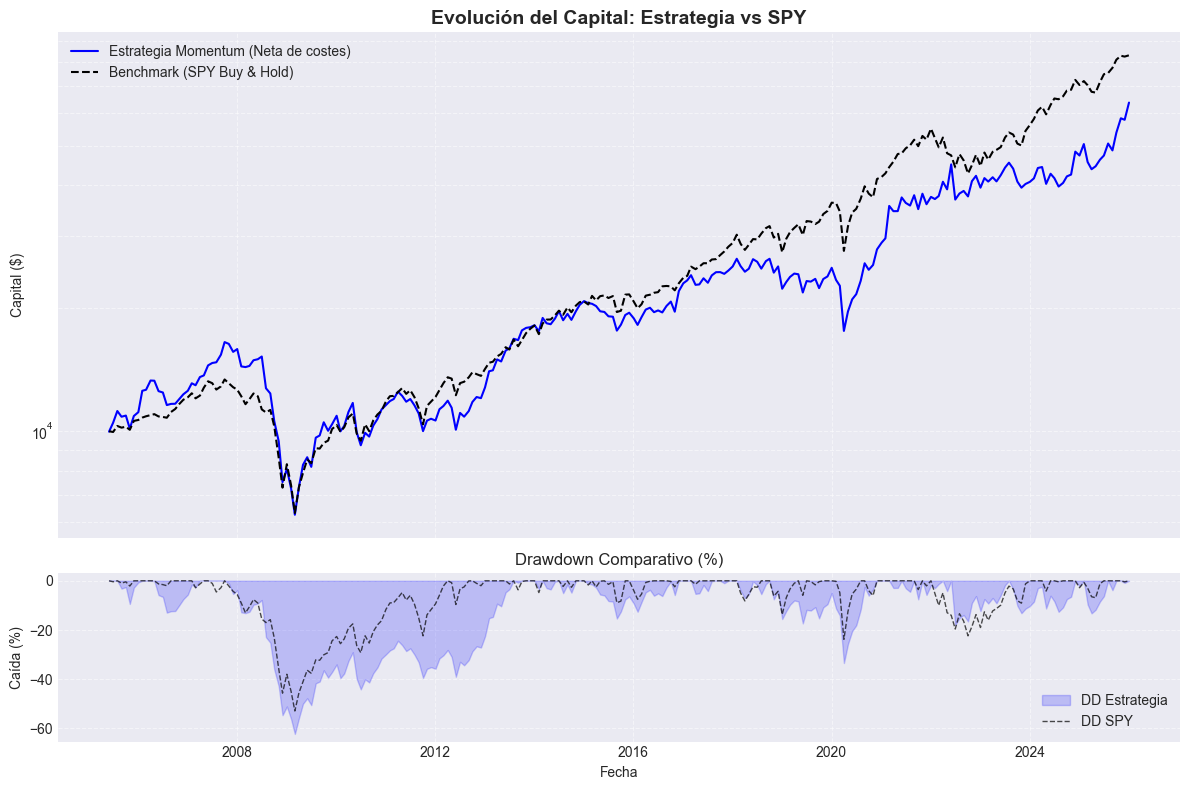

In [21]:
# ── LIBRERÍAS EXTRA NECESARIAS ─────────────────────────────
import yfinance as yf
import numpy as np

print("\nDescargando datos del Benchmark (SPY)...")

# 1. Descargamos el SPY para las fechas de nuestro backtest
start_date = nav_df.index[0]
end_date   = nav_df.index[-1] + pd.Timedelta(days=5) # Margen de seguridad

spy_data = yf.download('SPY', start=start_date, end=end_date)
# Aseguramos compatibilidad con distintas versiones de yfinance
if isinstance(spy_data.columns, pd.MultiIndex):
    spy_close = spy_data['Close']['SPY']
else:
    spy_close = spy_data['Adj Close']

# 2. Alineamos el SPY a nuestras fechas de rebalanceo (rellenando huecos)
spy_aligned = spy_close.reindex(nav_df.index, method='ffill')

# 3. Normalizamos el SPY para que empiece con nuestros mismos 10.000$
nav_df['bench_nav'] = (spy_aligned / spy_aligned.iloc[0]) * INITIAL_CASH

# 4. Calculamos los retornos periódicos (mensuales)
nav_df['strat_ret'] = nav_df['nav'].pct_change()
nav_df['bench_ret'] = nav_df['bench_nav'].pct_change()

# ── FUNCIÓN DE MÉTRICAS AVANZADAS ──────────────────────────
def calc_metrics(returns, nav_series):
    # Asumimos 12 periodos al año (rebalanceo mensual)
    PERIODS = 12
    RF_PERIODIC = (1 + RF_ANNUAL)**(1/PERIODS) - 1
    
    # CAGR
    years = (nav_series.index[-1] - nav_series.index[0]).days / 365.25
    cagr = (nav_series.iloc[-1] / nav_series.iloc[0]) ** (1 / years) - 1
    
    # Riesgo
    volatility = returns.std() * np.sqrt(PERIODS)
    
    # Max Drawdown
    peak = nav_series.cummax()
    drawdown = (nav_series - peak) / peak
    max_dd = drawdown.min()
    
    # Sharpe & Sortino
    excess_returns = returns - RF_PERIODIC
    sharpe = (excess_returns.mean() / returns.std()) * np.sqrt(PERIODS) if returns.std() > 0 else 0
    
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(PERIODS)
    sortino = (excess_returns.mean() * np.sqrt(PERIODS)) / downside_vol if downside_vol > 0 else 0
    
    return cagr, volatility, max_dd, sharpe, sortino

# Calculamos para Estrategia y Benchmark
strat_metrics = calc_metrics(nav_df['strat_ret'].dropna(), nav_df['nav'])
bench_metrics = calc_metrics(nav_df['bench_ret'].dropna(), nav_df['bench_nav'])

# ── IMPRESIÓN DEL INFORME COMPARATIVO ──────────────────────
print("\n" + "═" * 65)
print(f"{'📊 COMPARATIVA: ESTRATEGIA vs BENCHMARK (SPY)':^65}")
print("═" * 65)
print(f"{'Métrica':<20} | {'Estrategia':<18} | {'Benchmark (SPY)':<18}")
print("-" * 65)
print(f"{'Capital Final':<20} | {nav_df['nav'].iloc[-1]:>15,.2f} $ | {nav_df['bench_nav'].iloc[-1]:>15,.2f} $")
print(f"{'CAGR (Anualizado)':<20} | {strat_metrics[0]*100:>15.2f} % | {bench_metrics[0]*100:>15.2f} %")
print(f"{'Max Drawdown':<20} | {strat_metrics[2]*100:>15.2f} % | {bench_metrics[2]*100:>15.2f} %")
print(f"{'Volatilidad':<20} | {strat_metrics[1]*100:>15.2f} % | {bench_metrics[1]*100:>15.2f} %")
print(f"{'Ratio Sharpe':<20} | {strat_metrics[3]:>15.2f}   | {bench_metrics[3]:>15.2f}  ")
print(f"{'Ratio Sortino':<20} | {strat_metrics[4]:>15.2f}   | {bench_metrics[4]:>15.2f}  ")
print("═" * 65)

# ── GRÁFICO COMPARATIVO ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Curvas de Capital
ax1.plot(nav_df.index, nav_df['nav'], color='blue', linewidth=1.5, label='Estrategia Momentum (Neta de costes)')
ax1.plot(nav_df.index, nav_df['bench_nav'], color='black', linewidth=1.5, linestyle='--', label='Benchmark (SPY Buy & Hold)')
ax1.set_title('Evolución del Capital: Estrategia vs SPY', fontsize=14, fontweight='bold')
ax1.set_ylabel('Capital ($)')
ax1.set_yscale('log') 
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Drawdowns Comparativos
peak_strat = nav_df['nav'].cummax()
dd_strat = (nav_df['nav'] - peak_strat) / peak_strat

peak_bench = nav_df['bench_nav'].cummax()
dd_bench = (nav_df['bench_nav'] - peak_bench) / peak_bench

ax2.fill_between(nav_df.index, dd_strat * 100, 0, color='blue', alpha=0.2, label='DD Estrategia')
ax2.plot(nav_df.index, dd_bench * 100, color='black', linewidth=1, linestyle='--', alpha=0.7, label='DD SPY')
ax2.set_title('Drawdown Comparativo (%)', fontsize=12)
ax2.set_ylabel('Caída (%)')
ax2.set_xlabel('Fecha')
ax2.legend(loc='lower right')
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# ── CONFIGURACIÓN INICIAL ──────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

# ── CARGA DE DATOS (Asumiendo que ya están cargados) ─────────
print("Cargando y preparando datos...")
# Usamos '../data/' asumiendo estructura de proyecto de GitHub
data_path = Path('../data/sp500_clean.parquet')
if not data_path.exists():
    raise FileNotFoundError(f"No se encuentra el archivo de datos en {data_path}")

df = pd.read_parquet(data_path)
df = df[df['date'] >= '2005-01-01'].copy()
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

# ── PARÁMETROS FIJOS (Solo el Lookback varía) ──────────────
N_ASSETS_TARGET = 20
INITIAL_CASH_USD = 10_000   
SLIPPAGE_BPS = 0.002    
MIN_COMMISSION_USD = 1.0      
RF_ANNUAL = 0.03     

# ── CONSTRUCCIÓN DE PIVOTS INICIALES ─────────────────────────
close_pivot = df.pivot_table(index='date', columns='symbol', values='close').sort_index()
unadj_pivot = df.pivot_table(index='date', columns='symbol', values='unadjusted_close').sort_index()
sp500_pivot = df.pivot_table(index='date', columns='symbol', values='in_sp500').fillna(0).sort_index()

# ── CÁLCULO DE LIQUIDEZ (Dollar Volume - 6 meses de trading) 
# Estándar profesional: Dollar Volume = Volumen x PrecioUnadjusted
volume_pivot = df.pivot_table(index='date', columns='symbol', values='volume').sort_index()
dollar_volume = unadj_pivot * volume_pivot
avg_dollar_volume_126d = dollar_volume.rolling(window=126, min_periods=60).mean()

# ── FUNCIONES AUXILIARES ───────────────────────────────────
def get_close(symbol, date, pivot):
    if symbol in pivot.columns and date in pivot.index:
        p = pivot.at[date, symbol]
        if pd.notna(p) and p > 0:
            return float(p)
    return None

def get_last_known_close(symbol, before_date):
    if symbol in close_pivot.columns:
        past = close_pivot[symbol].loc[:before_date].dropna()
        if not past.empty:
            return float(past.iloc[-1])
    return 0.0

# ══════════════════════════════════════════════════════════
# FUNCIÓN MAESTRA DEL BACKTEST REALISTA
# ══════════════════════════════════════════════════════════
def run_realistic_momentum_backtest(lookback_days):
    print(f"  Ejecutando Backtest realista para Lookback: {lookback_days} días...")
    
    # 1. Señal de Momentum
    momentum_signal = close_pivot / close_pivot.shift(lookback_days) - 1
    
    # 2. Fechas de rebalanceo (T y T+1)
    all_dates = close_pivot.index
    valid_dates_for_signal = momentum_signal.dropna(how='all').index
    first_signal_date = valid_dates_for_signal[0] if not valid_dates_for_signal.empty else all_dates[lookback_days]
    valid_dates = all_dates[all_dates >= first_signal_date]
    
    signal_dates_raw = pd.Series(valid_dates).groupby([pd.Series(valid_dates).dt.year, pd.Series(valid_dates).dt.month]).last().values
    
    rebal_pairs = []
    for sd in signal_dates_raw:
        sd_ts = pd.Timestamp(sd)
        future_dates = all_dates[all_dates > sd_ts]
        if len(future_dates) > 0:
            rebal_pairs.append((sd_ts, pd.Timestamp(future_dates[0])))
    
    # 3. Motor de la Simulación
    portfolio = {}  
    last_rebal_price = {}  
    cash = INITIAL_CASH_USD
    nav_history = []
    trade_friction = 0 # Para sumar comisiones + slippage

    for signal_date, exec_date in rebal_pairs:
        if signal_date not in momentum_signal.index:
            continue
            
        # ── 0. Mark-to-Market y Delistings
        for symbol in list(portfolio.keys()):
            old_price = last_rebal_price[symbol]
            new_price = get_close(symbol, exec_date, close_pivot)
            if new_price is None:
                new_price = get_last_known_close(symbol, exec_date)
            ret = (new_price / old_price) if old_price > 0 else 0.0
            portfolio[symbol] *= ret
            last_rebal_price[symbol] = new_price

        # ── 1. Criterios de Universo Válido en T
        scores = momentum_signal.loc[signal_date].dropna()
        if signal_date in sp500_pivot.index:
            sp500_today_idx = sp500_pivot.loc[signal_date][sp500_pivot.loc[signal_date] == 1].index
        else:
            sp500_today_idx = pd.Index([])
            
        # ⚡ NUEVO: Filtro de Liquidez (Top 500 acciones más líquidas)
        if signal_date in avg_dollar_volume_126d.index:
            liquidity_scores = avg_dollar_volume_126d.loc[signal_date].dropna()
            valid_liquidity_idx = liquidity_scores.nlargest(500).index
        else:
            valid_liquidity_idx = pd.Index([])

        valid_symbols_base = sp500_today_idx.intersection(valid_liquidity_idx)
        
        valid_scores = scores[
            scores.index.isin(valid_symbols_base) &
            scores.index.map(lambda s: get_unadj_close(s, exec_date, unadj_pivot) is not None)
        ]
        
        top20_set = set(valid_scores.nlargest(N_ASSETS_TARGET).index)
        
        portfolio_set = set(portfolio.keys())
        # Forzar liquidación si una acción de cartera desapareció en exec_date
        for sym in list(portfolio_set):
            if get_close(sym, exec_date, close_pivot) is None:
                top20_set.discard(sym)
                
        group_b_sell = portfolio_set - top20_set
        group_c_buy = top20_set - portfolio_set

        # ── 2. Vender Grupo B
        for symbol in group_b_sell:
            capital_value = portfolio[symbol]
            capital_after_slip = capital_value * (1 - SLIPPAGE_BPS)
            commission = MIN_COMMISSION_USD
            cash += (capital_after_slip - commission)
            trade_friction += (capital_value - capital_after_slip + commission)
            del portfolio[symbol]
            del last_rebal_price[symbol]

        # ── 3. Comprar Grupo C
        n_to_buy = len(group_c_buy)
        if n_to_buy > 0 and cash > 0:
            capital_per_asset = cash / n_to_buy
            for symbol in group_c_buy:
                unadj_price = get_unadj_close(symbol, exec_date, unadj_pivot)
                if unadj_price is None or unadj_price <= 0: continue
                
                buy_price_real = unadj_price * (1 + SLIPPAGE_BPS)
                shares_to_buy = np.floor(capital_per_asset / buy_price_real)
                if shares_to_buy <= 0: continue
                
                invested_capital = shares_to_buy * buy_price_real
                commission = MIN_COMMISSION_USD
                if cash < (invested_capital + commission): continue
                
                cash -= (invested_capital + commission)
                portfolio[symbol] = invested_capital
                last_rebal_price[symbol] = get_close(symbol, exec_date, close_pivot) 
                trade_friction += (invested_capital / buy_price_real * SLIPPAGE_BPS + commission)

        cash = max(cash, 0.0)
        
        # ── 4. NAV y Registro
        nav_after = cash + sum(portfolio.values())
        nav_history.append({'date': exec_date, 'nav': nav_after})

    # 4. Cálculo de Métricas Finales
    nav_series = pd.DataFrame(nav_history).set_index('date')['nav']
    
    first_nav_date = nav_series.index[0]
    last_nav_date = nav_series.index[-1]
    years_passed = (last_nav_date - first_nav_date).days / 365.25
    
    initial_nav = INITIAL_CASH_USD
    final_nav = nav_series.iloc[-1]
    total_return = (final_nav / initial_nav) - 1
    cagr = ((final_nav / initial_nav) ** (1 / years_passed)) - 1
    
    peak_nav = nav_series.cummax()
    drawdown_pct = (nav_series - peak_nav) / peak_nav
    max_drawdown = drawdown_pct.min()
    
    monthly_returns = nav_series.pct_change().dropna()
    PERIODS = 12
    volatility = monthly_returns.std() * np.sqrt(PERIODS)
    RF_PERIODIC = (1 + RF_ANNUAL)**(1/PERIODS) - 1
    excess_returns = monthly_returns - RF_PERIODIC
    sharpe_ratio = (excess_returns.mean() / monthly_returns.std()) * np.sqrt(PERIODS) if monthly_returns.std() > 0 else 0
    
    return {
        'lookback': lookback_days,
        'final_nav': final_nav,
        'total_return_pct': total_return * 100,
        'cagr_pct': cagr * 100,
        'max_drawdown_pct': max_drawdown * 100,
        'volatility_pct': volatility * 100,
        'sharpe_ratio': sharpe_ratio,
        'total_friction_usd': trade_friction,
        'nav_series': nav_series
    }

# ⚡ Función auxiliar para pivot unadjusted
def get_unadj_close(symbol, date, pivot):
    if symbol in pivot.columns and date in pivot.index:
        p = pivot.at[date, symbol]
        if pd.notna(p) and p > 0:
            return float(p)
    return None

# ══════════════════════════════════════════════════════════
# BUCLE PRINCIPAL: BARRIDO DE PARÁMETROS
# ══════════════════════════════════════════════════════════
LOOKBACK_VALUES = [60, 90, 120, 150, 180, 210, 240]
sweep_results = []

print(f"\nArrancando barrido de parámetros para Lookbacks: {LOOKBACK_VALUES}...")
for lb in LOOKBACK_VALUES:
    result = run_realistic_momentum_backtest(lb)
    sweep_results.append(result)

print("✅ Barrido completado con éxito")

Cargando y preparando datos...

Arrancando barrido de parámetros para Lookbacks: [60, 90, 120, 150, 180, 210, 240]...
  Ejecutando Backtest realista para Lookback: 60 días...
  Ejecutando Backtest realista para Lookback: 90 días...
  Ejecutando Backtest realista para Lookback: 120 días...
  Ejecutando Backtest realista para Lookback: 150 días...
  Ejecutando Backtest realista para Lookback: 180 días...
  Ejecutando Backtest realista para Lookback: 210 días...
  Ejecutando Backtest realista para Lookback: 240 días...
✅ Barrido completado con éxito


In [25]:
# ── CÁLCULO DEL BENCHMARK (SPY) ──────────────────────────────
RF_PERIODIC = 0.03
print("\nDescargando datos del Benchmark (SPY)...")
# Usamos las fechas de la primera serie de NAV como referencia para alinear
all_nav_indices = sweep_results[0]['nav_series'].index
start_date_yf = all_nav_indices[0]
end_date_yf = all_nav_indices[-1] + pd.Timedelta(days=5)

spy_yf = yf.download('SPY', start=start_date_yf, end=end_date_yf)
# Manejo de versiones de yfinance
spy_close = spy_yf['Close']['SPY'] if isinstance(spy_yf.columns, pd.MultiIndex) else spy_yf['Adj Close']

spy_aligned = spy_close.reindex(all_nav_indices, method='ffill')
spy_nav = (spy_aligned / spy_aligned.iloc[0]) * INITIAL_CASH_USD
spy_monthly_rets = spy_nav.pct_change().dropna()

# Métricas SPY
years_spy = (spy_nav.index[-1] - spy_nav.index[0]).days / 365.25
cagr_spy = ((spy_nav.iloc[-1] / spy_nav.iloc[0]) ** (1 / years_spy)) - 1
peak_spy = spy_nav.cummax()
max_dd_spy = ((spy_nav - peak_spy) / peak_spy).min()
vol_spy = spy_monthly_rets.std() * np.sqrt(12)
excess_rets_spy = spy_monthly_rets - RF_PERIODIC # Reutilizando de la función
sharpe_spy = (excess_rets_spy.mean() / spy_monthly_rets.std()) * np.sqrt(12)

# ── CREACIÓN DE LA TABLA COMPARATIVA FINALES ───────────────
results_for_df = []
for res in sweep_results:
    results_for_df.append({
        'Lookback (días)': res['lookback'],
        'Capital Final ($)': res['final_nav'],
        'CAGR (%)': res['cagr_pct'],
        'Max Drawdown (%)': res['max_drawdown_pct'],
        'Sharpe Ratio': res['sharpe_ratio'],
        'Fricción Total ($)': res['total_friction_usd']
    })

# Añadimos el Benchmark a la lista
results_for_df.append({
    'Lookback (días)': 'Benchmark (SPY)',
    'Capital Final ($)': spy_nav.iloc[-1],
    'CAGR (%)': cagr_spy * 100,
    'Max Drawdown (%)': max_dd_spy * 100,
    'Sharpe Ratio': sharpe_spy,
    'Fricción Total ($)': 0 # No calculada en Buy & Hold
})

final_comparison_df = pd.DataFrame(results_for_df).set_index('Lookback (días)')

print("\n" + "═" * 75)
print(f"{'📊 TABLA COMPARATIVA: BARRIDO DE PARAMETROS MOMENTUM (2005-Presente)':^75}")
print("═" * 75)
print(final_comparison_df.to_string(float_format="{:,.2f}".format))
print("═" * 75)

[*********************100%***********************]  1 of 1 completed


Descargando datos del Benchmark (SPY)...

═══════════════════════════════════════════════════════════════════════════
    📊 TABLA COMPARATIVA: BARRIDO DE PARAMETROS MOMENTUM (2005-Presente)    
═══════════════════════════════════════════════════════════════════════════
                 Capital Final ($)  CAGR (%)  Max Drawdown (%)  Sharpe Ratio  Fricción Total ($)
Lookback (días)                                                                                 
60                       37,500.22      6.58            -64.11          0.27           11,638.55
90                       55,207.45      8.65            -60.16          0.37            9,935.08
120                      45,821.39      7.71            -60.54          0.33            8,096.12
150                      38,063.60      6.79            -57.34          0.28            6,870.67
180                      57,503.94      9.02            -62.18          0.38            6,820.39
210                      80,110.82     10.91      

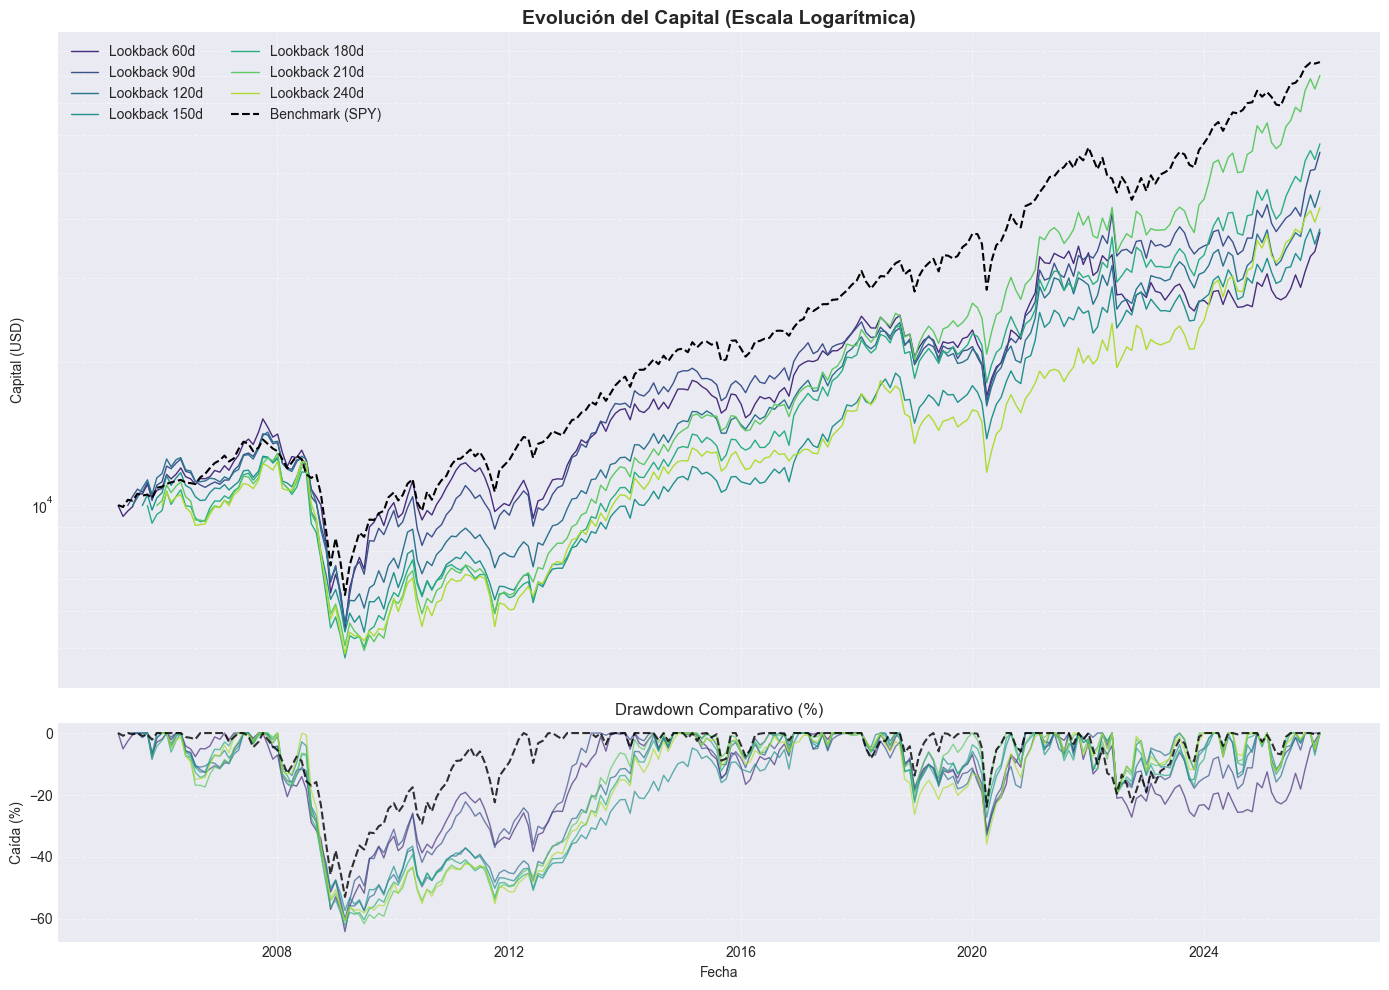

In [26]:
# ── GRÁFICOS COMPARATIVOS: CURVAS DE CAPITAL Y DRAWDOWN ───────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# 1. Graficamos Curvas de Capital (Escala Logarítmica)
# Paleta de colores para diferenciar los lookbacks
colors = sns.color_palette("viridis", len(LOOKBACK_VALUES))

for i, res in enumerate(sweep_results):
    ax1.plot(res['nav_series'].index, res['nav_series'], color=colors[i], linewidth=1, label=f'Lookback {res["lookback"]}d')

# Benchmark (Línea negra discontinua más gruesa)
ax1.plot(spy_nav.index, spy_nav, color='black', linewidth=1.5, linestyle='--', label='Benchmark (SPY)')

ax1.set_title('Evolución del Capital (Escala Logarítmica)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Capital (USD)')
ax1.set_yscale('log') # Escala Logarítmica es IMPRESCINDIBLE
ax1.legend(loc='upper left', ncol=2)
ax1.grid(True, which="both", ls="--", alpha=0.5)

# 2. Graficamos Max Drawdown Comparativo
# Graficamos el área rellena solo del peor (generalmente 60d o 90d) para no emborronar
# O una alternativa más limpia: solo graficar la línea de cada uno.
# Usaremos solo la línea para mayor claridad en el barrido.

for i, res in enumerate(sweep_results):
    dd_series = (res['nav_series'] / res['nav_series'].cummax() - 1) * 100
    ax2.plot(dd_series.index, dd_series, color=colors[i], linewidth=1, alpha=0.7)

# Benchmark DD (discontinuo)
dd_spy_series = ((spy_nav / spy_nav.cummax() - 1) * 100)
ax2.plot(dd_spy_series.index, dd_spy_series, color='black', linewidth=1.5, linestyle='--', alpha=0.8)

ax2.set_title('Drawdown Comparativo (%)', fontsize=12)
ax2.set_ylabel('Caída (%)')
ax2.set_xlabel('Fecha')
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()